# Definitions

### Memorization

A model memorizes if it generates samples that sit essentially on top of the training data, reproducing what it has already seen. For image generation, this means recreating training images at inference time, or stitching them together from patches of training data.

### Generalization

A model generalizes if it produces samples that are likely under the learned distribution but are not memorized. Formally, $x$ is an admissible generalized sample if it is not a memorized sample and the training density $p(x)$ is reasonably high.

## Creativity
Given an observed set, a creative sample $x$ should:
1. Differentiate from an ordinary generalization of the observed set (novelty).
2. Nonetheless remain compatible with the intrinsic patterns of the observed set, completing or extending them rather than abandoning them (structural consistency).

Creativity therefore cannot be reduced to low-probability sampling: a point far from the observed data could be improbable, but meaningless. Nor can it be captured by the observed data density $p(x)$ at all, since $p(x)$ cannot distinguish a structurally meaningful low-density gap from empty space. It requires a notion of compatibility with the \emph{geometry} of $p$ --- being ``on manifold'' --- rather than a threshold on density.

## Goal
Develop an *unsupervised* method for generating creative data points (or a creative distribution), learned solely from the geometry of an observed dataset with no external notion of creativity. We derive creativity directly from the observed data distribution $p$: we construct a probability measure $q$ - the *Creativity Measure* - such that sampling from $q$ (posterior) favors points that are creative with respect to $p$ (prior).

# Gibbs Tilted Formulation

Given an observed distribution $p$ and a distance measure $D$, let $f(x) := \mathbb{E}_{x' \sim p}[D(x,x')]$ be the expected distance from $x$ to the data. We define our objective as
\begin{equation}
    \min_{q} \; D_{\mathrm{KL}}(q \, \| \, p) - \lambda\, 
    \mathbb{E}_{x \sim q}[f(x)],
\end{equation}
where the minimization is over valid probability densities $q$ on the same domain as $p$. It can be shown that the optimizer of this problem is the *Gibbs-tilted density*,
\begin{equation}
    q_\lambda(x) = \frac{1}{Z_\lambda}\,p(x)\exp\{\lambda f(x)\},
\end{equation}
where
\begin{equation}
    Z_\lambda = \int p(x)\exp\{\lambda f(x)\}\,dx
\end{equation}
normalizes the distribution, and $\lambda \geq 0$ is the tilt strength, controlling how strongly $q_\lambda$ favors creative regions.

# The Information-Estimation Metric

For the distance $D$ we use the Information-Estimation Metric (IEM) of Ohayon et al., a distance function induced directly by the geometry of a probability density $p$. The density $p$ is progressively blurred through a Gaussian channel $y_\gamma = \gamma x + w_\gamma$, $w_\gamma \sim \mathcal{N}(0, \gamma I)$, where $\gamma$ is the signal-to-noise ratio (SNR). The IEM compares the score vector fields of the blurred density, $\nabla \log p_{y_\gamma}$, around two points, integrated over a range of blur levels:
\begin{equation}
    \mathrm{IEM}(x_1, x_2, \Gamma)
    = \left(\int_0^\Gamma \mathbb{E}_{w_\gamma}\!\left[\, f'(z_\gamma, \gamma)^2 \bigl\lVert \nabla \log p_{y_\gamma}(\gamma x_1 + w_\gamma) - \nabla \log p_{y_\gamma}(\gamma x_2 + w_\gamma)\bigr\rVert^2\,\right] d\gamma \right)^{1/2}.
\end{equation}
where
\begin{equation}
    z_\gamma(x_1, x_2) =: \log \left( \frac{p_{y_\gamma} (\gamma x_1 + w_\gamma)}{p_{y_\gamma} (\gamma x_2 + w_\gamma)} \right)
\end{equation}


# IEM-Driven Creativity Tilt

The tilted density re-weights the prior: $q_\lambda(x) \propto p(x) \cdot \exp(\lambda \cdot \mathbb{E}_{x' \sim p}[D(x', x)])$, concentrating mass on points that are far from the observed distribution.

In [1]:
import sys, math, torch, matplotlib.pyplot as plt
sys.path.insert(0, '.')
from creativity_measure import *
dtype = torch.float64
torch.set_default_dtype(dtype)
torch.set_default_device(default_device())

## Swiss Roll with a hole

In [67]:
# Swiss Roll with a hole — the dataset for all experiments below.
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture

D = 2
N_SAMPLES_HOLE = 5000
N_COMPONENTS_HOLE = 24
T_HOLE_MIN, T_HOLE_MAX = 8.5, 9.5    # gap in the middle wrap (t ∈ [1.5π, 4.5π] ≈ [4.7, 14.1])

X_np2, t_np2 = make_swiss_roll(n_samples=N_SAMPLES_HOLE, noise=0.0, random_state=42)
X2d_np2 = X_np2[:, [0, 2]]

keep = ~((t_np2 >= T_HOLE_MIN) & (t_np2 <= T_HOLE_MAX))
X_kept = X2d_np2[keep]
X_hole = X2d_np2[~keep]

gmm2 = GaussianMixture(n_components=N_COMPONENTS_HOLE, covariance_type='spherical',
                       random_state=42).fit(X_kept)

MEANS        = torch.tensor(gmm2.means_,       dtype=dtype)
VARS         = torch.tensor(gmm2.covariances_, dtype=dtype)
LOG_WEIGHTS  = torch.log(torch.tensor(gmm2.weights_, dtype=dtype))
K = MEANS.shape[0]

# Downsample hole points for visualization (MISSING markers)
rng_vis = torch.Generator().manual_seed(0)
vis_idx = torch.randperm(len(X_hole), generator=rng_vis, device='cpu')[:50]  # CPU: indexes the numpy X_hole
MISSING = torch.tensor(X_hole[vis_idx], dtype=dtype)

def log_pX(x):
    diff    = x.unsqueeze(-2) - MEANS
    quad    = diff.pow(2).sum(-1) / VARS
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * VARS) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def log_pY(y, gamma):
    gamma   = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var     = gamma**2 * VARS + gamma
    diff    = y.unsqueeze(-2) - gamma * MEANS
    quad    = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * var) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def roll_hole_sample(n):
    idx = torch.multinomial(torch.exp(LOG_WEIGHTS), n, replacement=True)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype)

p_roll2 = Density(log_pX, log_pY, sample_fn=roll_hole_sample, d=2)
print(f"Swiss Roll with hole: {K} components, hole t∈[{T_HOLE_MIN}, {T_HOLE_MAX}]")

grid_points_roll2, XX, YY, cell_area = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
log_p_grid_roll2 = p_roll2.log_p_X(grid_points_roll2)
x_refs = p_roll2.sample(32, seed=123)
print(f"Grid: {grid_points_roll2.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Swiss Roll with hole: 24 components, hole t∈[8.5, 9.5]
Grid: 2500 points, cell_area=0.3748; refs: torch.Size([32, 2])


# Experiments: Sensitivity of the Global Creativity Measure (Swiss Roll with a hole)

How does the generalized global IEM creativity tilt `log q_λ(x) ∝ log p(x) + λ·E_{x'~p}[D_Global_IEM(x', x)]`
respond to its knobs? Tried applying different parameters on the **Swiss Roll with a hole** density example. 

All distances use `GeneralizedGlobalIEMDistance`.
`σ = 1/√γ`, so small γ <-> high noise (`σ_max`) and large γ <-> low noise (`σ_min`).

- **Exp 1** — γ integration windows (i.e. different σ values).
- **Exp 2** — integration density (number of γ grid points).
- **Exp 3** — number and choise of reference points `x_refs` for `E_{x'~p}[D_Global_IEM(x', x)]`, for every x.
- **Exp 4** — choice of `f` (identity vs squared).

In [ ]:
# Shared settings for all sensitivity experiments below.
EXP_NUM_EPS = 16                            # Brownian path samples for all experiments
EXP_LAMBDAS = [2.0, 4.0, 6.0, 8.0, 10.0]    # λ rows used by the Exp 1 grids

### Exp 1a — effect of the γ integration window (σ_min / σ_max)

Split the full window `[2^-10, 2^10]` into 5 **equal-width** γ sub-windows `[γ_0,γ_1], [γ_1,γ_2], …` (equal Δγ),
each integrated on a **log-spaced** grid, and integrate the IEM distance over each separately. Columns = sub-window, rows = λ.

In [69]:
# Exp 1a (compute): one IEM distance per equal-width gamma sub-window (loguniform grid within each).
GAMMA_LO, GAMMA_HI = 2.0**-10, 2.0**10      # very small -> large
N_PANELS, N_GAMMA_PER_PANEL = 5, 50         # 5 equal-width windows, loguniform integration density each
gamma_edges = torch.linspace(GAMMA_LO, GAMMA_HI, N_PANELS + 1, dtype=dtype)  # equal Δγ breakpoints

exp1_expected_dists, exp1_labels = [], []
for k in range(N_PANELS):
    g0, g1 = gamma_edges[k].item(), gamma_edges[k + 1].item()
    gammas_k = torch.logspace(math.log2(g0), math.log2(g1), N_GAMMA_PER_PANEL, base=2, dtype=dtype)  # loguniform grid within the window
    D_k = GeneralizedGlobalIEMDistance(p_roll2, gammas_k, num_eps=EXP_NUM_EPS,
                                       f_type=IEMFType.IDENTITY)
    exp1_expected_dists.append(expected_distance(D_k, grid_points_roll2, x_refs))
    exp1_labels.append(f"γ∈[{g0:.3g}, {g1:.3g}]")
    print(f"panel {k}: {exp1_labels[-1]} done")

panel 0: γ∈[0.000977, 205] done
panel 1: γ∈[205, 410] done
panel 2: γ∈[410, 614] done
panel 3: γ∈[614, 819] done
panel 4: γ∈[819, 1.02e+03] done


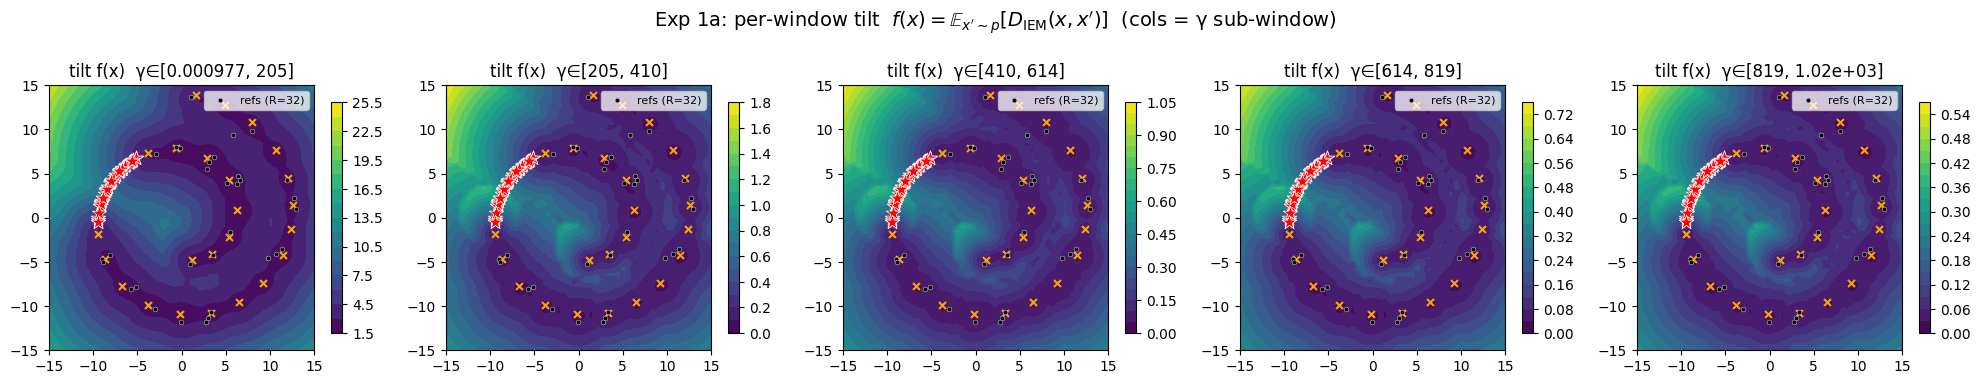

In [71]:
# Exp 1a (tilt fields): 1x5 row of the per-window tilt f(x) = E_{x'~p}[D_IEM(x, x')], one per γ sub-window.
fig, axes = plt.subplots(1, N_PANELS, figsize=(4 * N_PANELS, 3.6))
for ax, f_grid_k, label in zip(axes, exp1_expected_dists, exp1_labels):
    plot_field(f_grid_k, XX, YY, ax=ax, title=f"tilt f(x)  {label}",
               marked=MEANS, missing=MISSING, refs=x_refs)
fig.suptitle(r"Exp 1a: per-window tilt  $f(x) = \mathbb{E}_{x'\sim p}[D_{\mathrm{IEM}}(x, x')]$  (cols = γ sub-window)",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

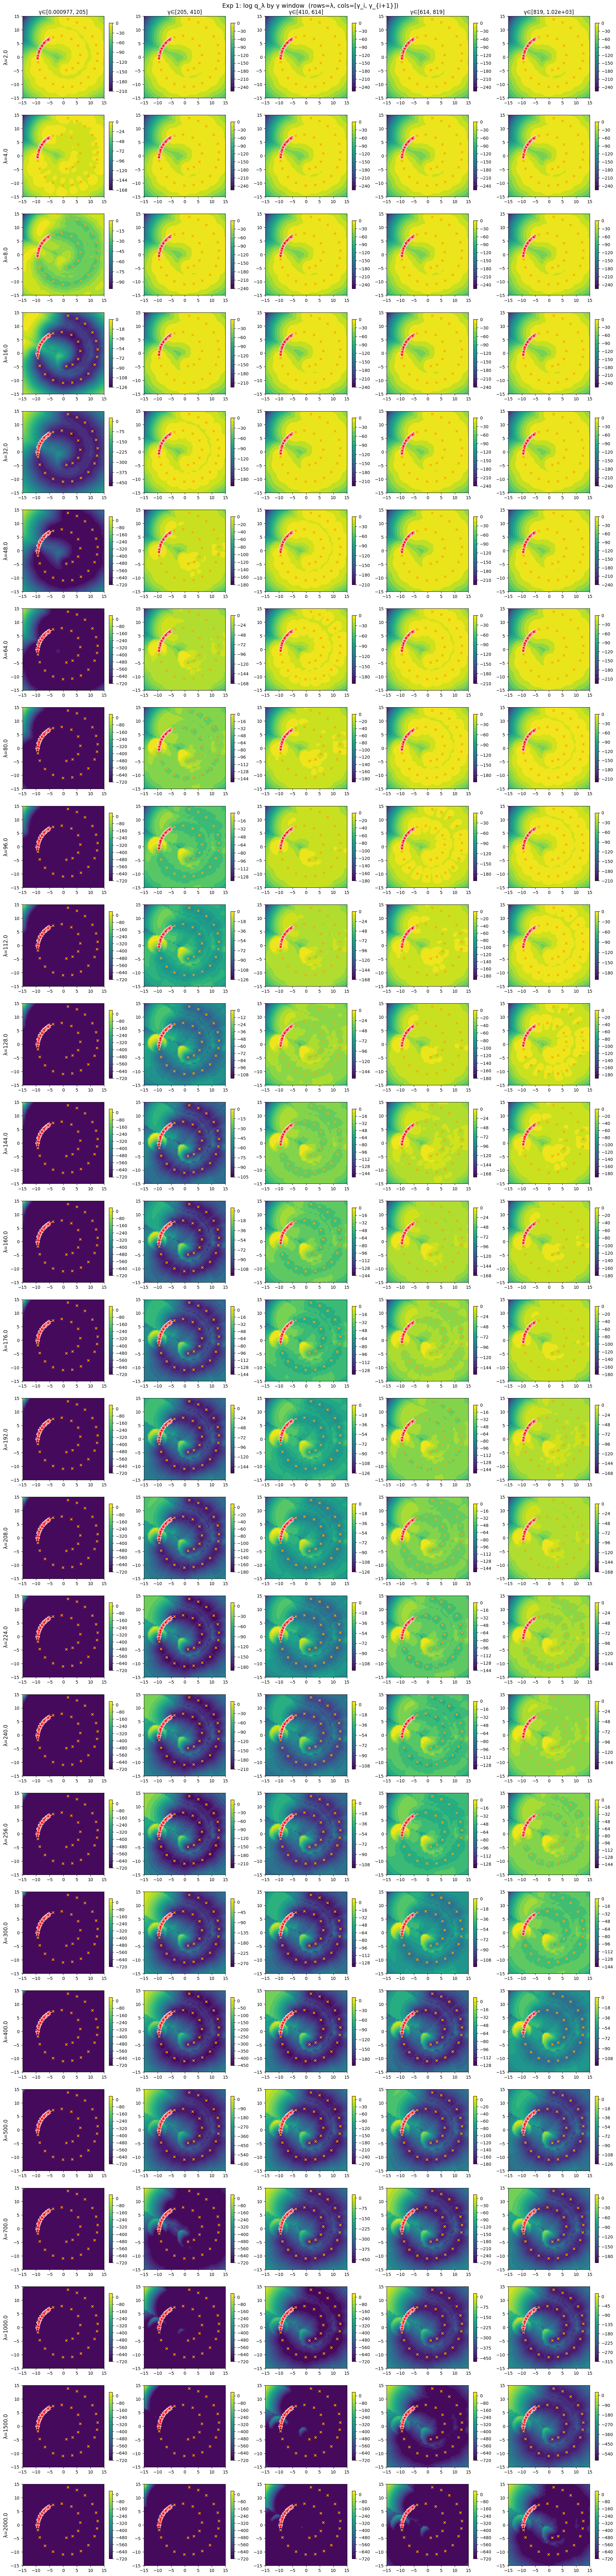

In [70]:
# Exp 1a (plot): grid of log q_λ. rows = λ, cols = gamma sub-window.
EXP_LAMBDAS_1a = [2.0, 4.0, 8.0, 16.0, 32.0, 48.0, 64.0, 80.0, 96.0, 112.0, 128.0, 144.0, 160.0, 176.0, 192.0, 208.0, 224.0, 240.0, 256.0, 300.0, 400.0, 500.0, 700.0, 1000.0, 1500.0, 2000.0]
fig, _ = lambda_sweep(
    log_p_grid_roll2, exp1_expected_dists, cell_area, XX, YY,
    lambdas=EXP_LAMBDAS_1a, field_labels=exp1_labels,
    row_labels=[f"λ={L}" for L in EXP_LAMBDAS_1a],
    marked=MEANS, missing=MISSING, panel_w=4, panel_h=3.2,
)
fig.suptitle("Exp 1: log q_λ by γ window  (rows=λ, cols=[γ_i, γ_{i+1}])", fontsize=14, y=1)
plt.show()

($\sigma = \frac{1}{\sqrt{\gamma}}$, so $\gamma = \frac{1}{\sigma^2}$. Hence: low $\gamma$ <-> large $\sigma$ -> heavy blur. high $\gamma$ <-> small $\sigma$ -> little noise)

**For small $\gamma$ values**, the noise floor $\gamma$ dominates the data term $\gamma^2 S^2$, the modes overlap, and the mixture collapses to a single Gaussian, whose score is linear:

$$\nabla\log p_{Y_\gamma}(y)=-\frac{y-\gamma\bar\mu}{\gamma^2 S^2+\gamma}.$$

For the blurred variance: $\mathrm{var}:=\gamma^2 S^2+\gamma$.
The IEM compares the score field at the noised images of $x_1$ and $x_2$ along the same Brownian path, therefore:

$$y_1=\gamma x_1+w_\gamma,\qquad y_2=\gamma x_2+w_\gamma,$$

$$s_1=-\frac{y_1-\gamma\bar\mu}{\mathrm{var}}=-\frac{\gamma x_1+w_\gamma-\gamma\bar\mu}{\mathrm{var}},\qquad s_2=-\frac{y_2-\gamma\bar\mu}{\mathrm{var}}=-\frac{\gamma x_2+w_\gamma-\gamma\bar\mu}{\mathrm{var}}.$$

$$s_1-s_2=-\frac{(\gamma x_1+w_\gamma-\gamma\bar\mu)-(\gamma x_2+w_\gamma-\gamma\bar\mu)}{\mathrm{var}}=-\frac{\gamma(x_1-x_2)}{\gamma^2 S^2+\gamma} = -\frac{x_1-x_2}{\gamma S^2+1}.$$

$$\lVert s_1-s_2\rVert^2=\frac{\lVert x_1-x_2\rVert^2}{(\gamma S^2+1)^2}.$$

- **Conclusion 1a**: When we take $\gamma\to0$, the denominator $\gamma S^2+1\to1$, so $\lVert s_1-s_2\rVert^2\xrightarrow{\ \gamma\to0\ }\lVert x_1-x_2\rVert^2$, the integrand reduces to plain squared Euclidean distance. Therefore, the density is just pushed away when increasing $\lambda$.


**In the opposite limit (large $\gamma$, small $\sigma$, little blur)** the noise floor is negligible, so $\mathrm{var}=\gamma^2 S^2+\gamma\to\gamma^2 S^2$. The modes stay separated, since $\frac{\gamma\lVert\mu_i-\mu_j\rVert}{\sqrt{\mathrm{var}}}\to\frac{\lVert\mu_i-\mu_j\rVert}{S}$ (a fixed nonzero separation), and $p$ keeps its full multimodal structure. The score is no longer linear, so the cancellation of 1a no longer applies: $\lVert s_1-s_2\rVert^2$ now depends on *where* $x_1,x_2$ sit relative to the modes, not just on $\lVert x_1-x_2\rVert$.

Concretely, as $\sigma\to0$ the noised observation $y=\gamma x+w_\gamma$ concentrates and the marginal score recovers the clean-data score up to the $\gamma$ scaling:

$$\nabla\log p_{Y_\gamma}(\gamma x+w_\gamma)\;\xrightarrow{\ \gamma\to\infty\ }\;\frac{1}{\gamma}\,\nabla\log p_X(x).$$

Taking the difference and squaring then gives:

$$s_1-s_2\;\longrightarrow\;\frac{1}{\gamma}\big(\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big),$$

$$\lVert s_1-s_2\rVert^2\;\longrightarrow\;\frac{1}{\gamma^2}\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert^2.$$

The integrand **factorizes** into a $\gamma$-dependent magnitude $\frac{1}{\gamma^2}$ and a $\gamma$-independent shape $\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert^2$.

- **Conclusion 1b (stable shape).** Carrying the factorization through the metric's square root,

  $$\mathrm{IEM}_{\text{window}}=\underbrace{\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert}_{\text{shape, }\gamma\text{-independent}}\cdot\;c_{\text{window}},\qquad c_{\text{window}}:=\sqrt{\int_{\text{window}}\frac{d\gamma}{\gamma^2}}.$$

  Every high-$\gamma$ window measures the *same* geometric field, scaled only by $c_{\text{window}}$, which shrinks as the window moves up. Since $\lambda$ only sets contrast, the geometry emerges when the product $\lambda\,c_{\text{window}}$ overcomes $\log p$, so higher windows (smaller $c_{\text{window}}$) need proportionally larger $\lambda$ to reach the same shared shape.

- **Conclusion 1c (geometry, not distance).** Unlike 1a, the surviving field $\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert$ is set by the *shape* of $p$, not by position: it is large between points the density treats as structurally different rather than between points that are merely far apart. The tilt $q_\lambda\propto p\,e^{\lambda f}$ therefore rewards novel, on-manifold regions (the hole in $p$) over distant off-manifold ones. The creativity behavior the measure is meant to exhibit, and the regime the coarse Euclidean window of 1a cannot reach.

- **Conclusion 1d (choosing the integration window in high-D).** 1a–1c say the low-$\gamma$ (= high-$\sigma$) region contributes only a Euclidean floor while the geometry lives at high $\gamma$ (low $\sigma$), so the window should start above the floor. The crossover is governed by the channel variance $\gamma^2\,\mathrm{Cov}+\gamma I$ switching from noise-dominated ($\gamma I$) to data-dominated, at $\gamma\sim\frac{1}{\sigma_{\text{data}}^2}$, or equivalently, in $\sigma$ units, at $\sigma\sim\sigma_{\text{data}}$.
  - **Outer bounds** come from the denoiser's valid range $\sigma\in[\sigma_{\min},\sigma_{\max}]$ (EDM defaults $[0.002,\,80]$, i.e. $\gamma\in[\,\frac{1}{\sigma_{\max}^2},\,\frac{1}{\sigma_{\min}^2}\,]\approx[\,1.6\times10^{-4},\ 2.5\times10^{5}\,]$). Outside it the learned score is invalid.
  - **Lower cut** drops the high-$\sigma$ floor: keep $\sigma < C\,\sigma_{\text{data}}$ for a small constant $C$, i.e. $\gamma_{\text{lo}} > \frac{1}{(C\,\sigma_{\text{data}})^2}$. Here $\sigma_{\text{data}}$ is the fixed data scale the denoiser was trained at, which is an explicit EDM hyperparameter (default $0.5$ for images scaled to $[-1,1]$), or the sample standard deviation of the data.

  Choosing in $\sigma$-space is natural because $\sigma$ is noise in data units and $\sigma_{\text{data}}$ is the scale EDM is built around: the preconditioner $c_{\text{skip}}=\frac{\sigma_{\text{data}}^2}{\sigma^2+\sigma_{\text{data}}^2}$ pivots at $\sigma_{\text{data}}$ (staying $\approx1$ for $\sigma\ll\sigma_{\text{data}}$ and $\approx0$ for $\sigma\gg\sigma_{\text{data}}$), marking the same noise-floor-vs-data crossover. With the floor removed, $\lambda$ becomes a clean contrast knob (1b) with no Euclidean blow-out to bound it from above.

- **Heuristic Suggestion 1e (choosing $\lambda$).** When initially choosing $\lambda$, consider the spread of the two competing terms in $\log q_\lambda=\log p+\lambda f$, and match them:
  $$\lambda_0 \sim \frac{\text{spread}(\log p)}{\text{spread}(f)}.$$
  In image space the data is extremely sparse. Measure spread only on the data itself: evaluate $\log p$ and $f$ on real samples (not the ambient grid), then take their std or a tight inter-quantile range:
  ```python
  # logp, f evaluated on real samples x_data, not a grid
  spread_logp = logp.std()   # or q(logp, 0.75) - q(logp, 0.25)
  spread_f    = f.std()
  lambda_0    = spread_logp / spread_f
  ```
  Since the floor is cut (1d), $\lambda$ is monotone-safe, so sweep $\{0.3,1,3,10,etc.\}\times\lambda_0$ and take the largest $\lambda$ whose samples stay on-manifold.

In [6]:
# Exp 1 summary (compute): floor-cut sweep over C, each window self-calibrated.
S = torch.sqrt(VARS).mean().item()             # per-component std (1a crossover scale)
N_GAMMA = 50

C_OPTIONS = [None, 2.0, 1.0, 0.75, 0.5]        # None = no cut (full window)
cut_results = []

for C in C_OPTIONS:
    if C is None:
        g_lo = 2.0 ** -10
        label = "no cut"
    else:
        g_lo = 1.0 / (C * S) ** 2
        label = f"C={C:g} (γ_lo={g_lo:.3g})"

    gammas = torch.logspace(math.log2(g_lo), 10, N_GAMMA, base=2, dtype=dtype)
    dist = GeneralizedGlobalIEMDistance(p_roll2, gammas, num_eps=EXP_NUM_EPS,
                                        f_type=IEMFType.IDENTITY)

    f_grid = expected_distance(dist, grid_points_roll2, x_refs)   # (G,)
    f_refs = expected_distance(dist, x_refs, x_refs)              # (R,)
    logp_refs = p_roll2.log_p_X(x_refs)                          # (R,)
    lam0 = (logp_refs.std() / f_refs.std()).item()

    cut_results.append({"label": label, "f": f_grid, "lam0": lam0})
    print(f"{label:22s} done   λ₀={lam0:.3g}")

print(f"\nS={S:.3f}, crossover γ≈1/S²={1/S**2:.3g}")

no cut                 done   λ₀=3.82
C=2 (γ_lo=0.539)       done   λ₀=3.87
C=1 (γ_lo=2.16)        done   λ₀=4.37
C=0.75 (γ_lo=3.83)     done   λ₀=5.01
C=0.5 (γ_lo=8.62)      done   λ₀=6.69

S=0.681, crossover γ≈1/S²=2.16


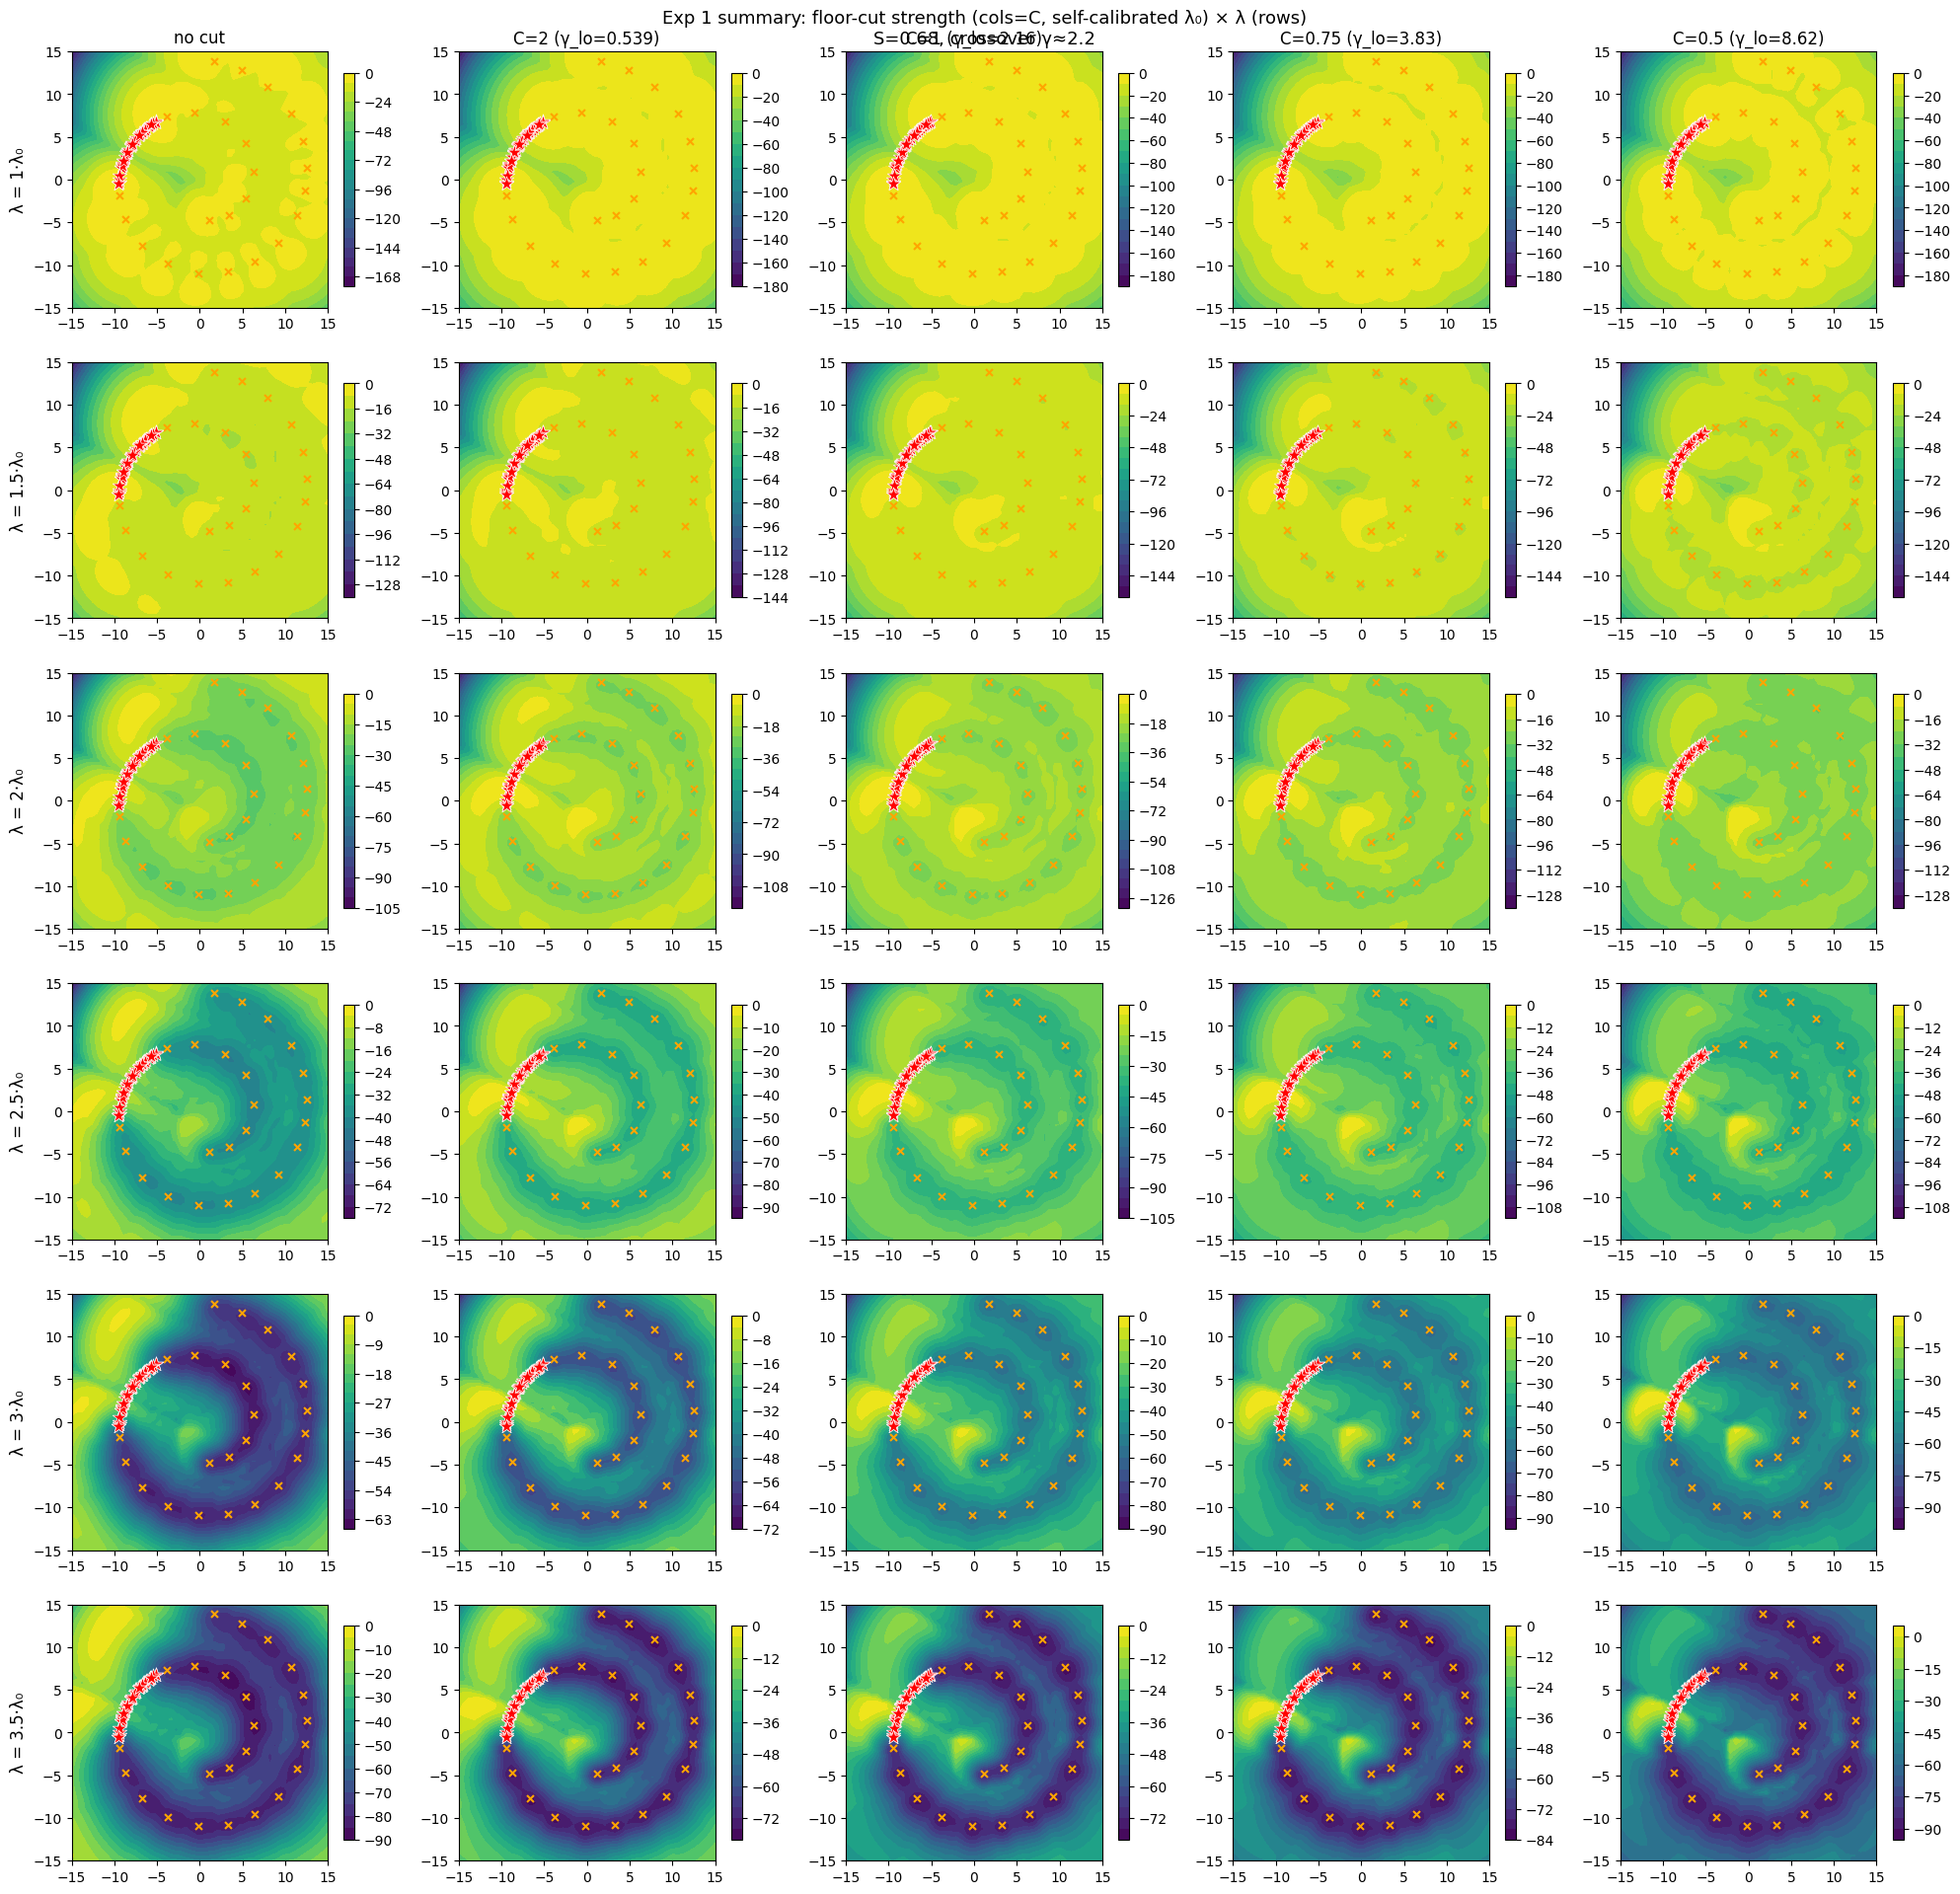

In [7]:
# Exp 1 summary (plot): rows = λ multiples (per-column λ₀), cols = C options.
lambda_mults = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
fig, _ = lambda_sweep(
    log_p_grid_roll2, [res["f"] for res in cut_results], cell_area, XX, YY,
    lambda0=[res["lam0"] for res in cut_results], multipliers=lambda_mults,
    field_labels=[res["label"] for res in cut_results],
    row_labels=[f"λ = {m:g}·λ₀" for m in lambda_mults],
    marked=MEANS, missing=MISSING, panel_w=4, panel_h=3.2,
)
fig.suptitle("Exp 1 summary: floor-cut strength (cols=C, self-calibrated λ₀) × λ (rows)\n"
             f"S={S:.2f}, crossover γ≈{1/S**2:.2g}", fontsize=13, y=1.0)
plt.show()

## Adopted settings — after Exp 1

Exp 1 fixes the **floor-cut window** `C = 0.75` → `γ_lo = 1/(C·S)² ≈ 3.83`, `γ_hi = 2¹⁰`, and the
matching self-calibrated **λ₀ ≈ 5.01** (computed at the density used in Exp 1's sweep). Experiments
below sweep `λ = {2.5, 3, 3.5}·λ₀`.

In [8]:
# Adopted from Exp 1: floor-cut window C=0.75 and its matching data-derived λ₀.
S        = torch.sqrt(VARS).mean().item()   # per-component std (1a crossover scale)
C        = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2               # ≈ 3.83   (σ_max = 1/√γ_lo)
GAMMA_HI = 2.0 ** 10                        #          (σ_min = 1/√γ_hi)
LAMBDA_MULTS = [2.5, 3.0, 3.5]              # rows in following experiment grids = m · λ₀

# λ₀ self-calibrated on the window, at the density used in Exp 1's sweep (50 γ-points).
_gammas1 = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), 50, base=2, dtype=dtype)
_D1      = GeneralizedGlobalIEMDistance(p_roll2, _gammas1, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
LAMBDA_0 = (p_roll2.log_p_X(x_refs).std() / expected_distance(_D1, x_refs, x_refs).std()).item()
print(f"After Exp 1: C={C}, γ_lo={GAMMA_LO:.3g}, γ_hi={GAMMA_HI:.0f}, λ₀={LAMBDA_0:.3g}; "
      f"λ rows = {[round(m * LAMBDA_0, 2) for m in LAMBDA_MULTS]}")

After Exp 1: C=0.75, γ_lo=3.83, γ_hi=1024, λ₀=5.01; λ rows = [12.54, 15.04, 17.55]


### Exp 2 — effect of integration density

Vary the number of γ grid points `N_γ` over the **adopted floor-cut window** `γ ∈ [γ_lo, γ_hi] ≈ [3.83, 1024]`
(C=0.75) with a constant step: `{50, 100, 150, 200, 250}` (sparse → dense). Columns = `N_γ`,
rows = `λ = {2.5, 3, 3.5}·λ₀` with the matching `λ₀ ≈ 5.01` held fixed. The fields should
converge as the integral is resolved more finely.

In [9]:
# Exp 2 (compute): one IEM distance per integration density, on the adopted window [γ_lo, γ_hi].
EXP2_DENSITIES = [10, 25, 50, 100, 200]
exp2_expected_dists = []
for n in EXP2_DENSITIES:
    gammas_n = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), n, base=2, dtype=dtype)
    D_n = GeneralizedGlobalIEMDistance(p_roll2, gammas_n, num_eps=EXP_NUM_EPS,
                                       f_type=IEMFType.IDENTITY)
    exp2_expected_dists.append(expected_distance(D_n, grid_points_roll2, x_refs))
    print(f"density N_γ={n} done")

density N_γ=10 done
density N_γ=25 done
density N_γ=50 done
density N_γ=100 done
density N_γ=200 done


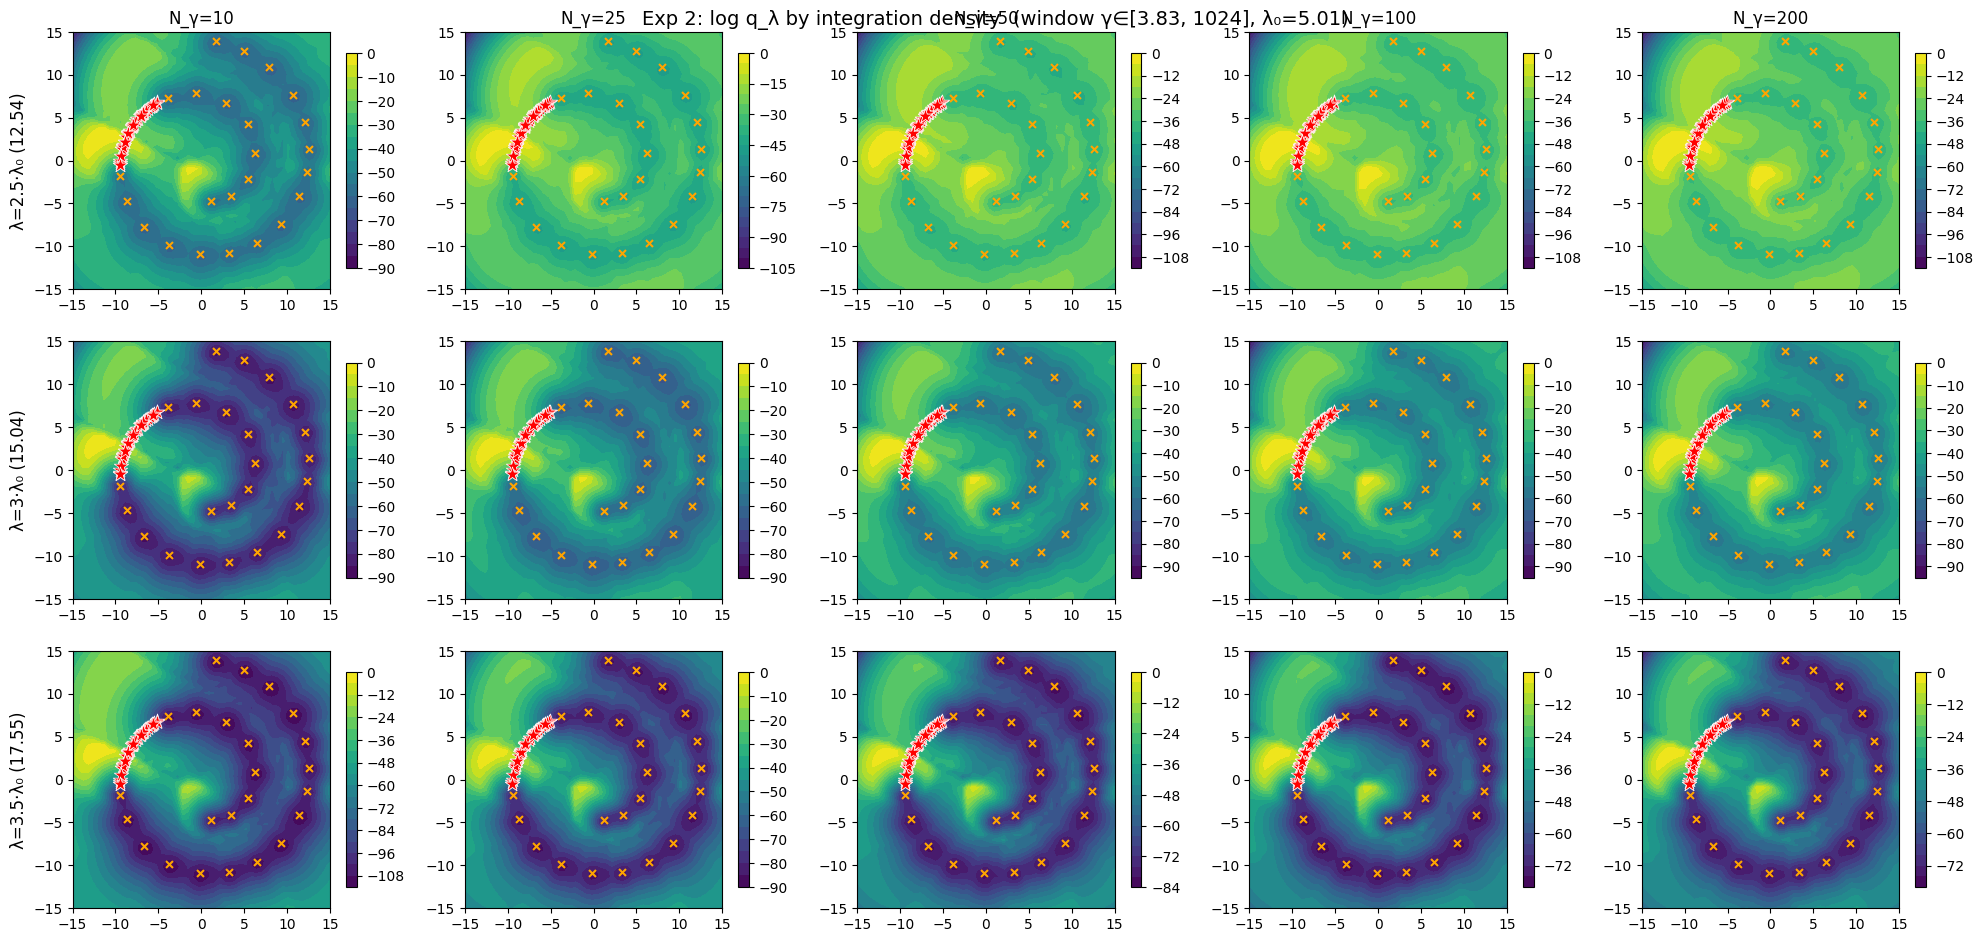

In [10]:
# Exp 2 (plot): 3x5 grid of log q_λ. rows = λ (multiples of λ₀), cols = integration density N_γ.
fig, _ = lambda_sweep(
    log_p_grid_roll2, exp2_expected_dists, cell_area, XX, YY,
    lambda0=LAMBDA_0, multipliers=LAMBDA_MULTS,
    field_labels=[f"N_γ={d}" for d in EXP2_DENSITIES],
    row_labels=[f"λ={m:g}·λ₀ ({m*LAMBDA_0:.2f})" for m in LAMBDA_MULTS],
    marked=MEANS, missing=MISSING, panel_w=4, panel_h=3.2,
)
fig.suptitle(f"Exp 2: log q_λ by integration density  "
             f"(window γ∈[{GAMMA_LO:.2f}, {GAMMA_HI:.0f}], λ₀={LAMBDA_0:.2f})", fontsize=14)
plt.show()

The γ-grid resolution $N_\gamma$ enters $\log p(x) + \lambda f(x)$ only through $f$ (the tilt), since $\log p$ is independent of it. The estimate of $f$ converges to within negligible error for $N_\gamma \geq 25$, so I adopt $N_\gamma = 50$ for the following experiments.

- **Conclusion 2**. With $f =$ identity and the lower-window cut applied, $N_\gamma \geq 25$ suffices in 2D. Because $N_\gamma$ resolves a one-dimensional integral over γ (independent of the data dimension $d$), a similarly small value is expected to suffice in higher $d$.

## Adopted settings — after Exp 2 (merged)

Adding Exp 2's result to Exp 1's: the integration density **N_γ = 50** is converged on this window,
so the adopted γ grid is frozen. Full setting carried into Exp 3 onward:
window `C=0.75` (`γ_lo≈3.83`, `γ_hi=2¹⁰`), `N_γ=50`, `λ₀≈5.01`, rows `λ={2.5,3,3.5}·λ₀`.

In [11]:
# Merged adoption (Exp 1 + Exp 2): window C=0.75, density N_γ=50, matching λ₀ — used by Exp 3 onward.
S        = torch.sqrt(VARS).mean().item()   # per-component std (1a crossover scale)
C        = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2               # ≈ 3.83   (σ_max = 1/√γ_lo)
GAMMA_HI = 2.0 ** 10                        #          (σ_min = 1/√γ_hi)
N_GAMMA  = 50                               # Exp 2: converged on this window
LAMBDA_MULTS = [2.5, 3.0, 3.5]              # rows in following experiment grids = m · λ₀

# Adopted γ grid and the λ₀ self-calibrated on it; held fixed across Exp 3 onward.
GAMMAS   = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)
_D0      = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
LAMBDA_0 = (p_roll2.log_p_X(x_refs).std() / expected_distance(_D0, x_refs, x_refs).std()).item()
print(f"Adopted (Exp 1+2): C={C}, γ_lo={GAMMA_LO:.3g}, γ_hi={GAMMA_HI:.0f}, N_γ={N_GAMMA}, "
      f"λ₀={LAMBDA_0:.3g}; λ rows = {[round(m * LAMBDA_0, 2) for m in LAMBDA_MULTS]}")

Adopted (Exp 1+2): C=0.75, γ_lo=3.83, γ_hi=1024, N_γ=50, λ₀=5.01; λ rows = [12.54, 15.04, 17.55]


### Exp 3 — effect of the number of x_refs

The creativity score is `E_{x'~p}[D_IEM(x', x)]` approximated as a mean over reference samples.
Vary the number of refs `R` geometrically: `{4, 8, 16, 32, 64}` (nested prefixes of one 64-ref draw),
on the adopted window/density and the fixed `λ₀`. Columns = `R`, rows = `λ = {2.5, 3, 3.5}·λ₀`.
The estimate should stabilize as `R` grows; `R=32` is the adopted reference count.

In [12]:
# Exp 3a (compute): pairwise distance to the LARGEST ref set once, then nested prefix means.
EXP3_NREFS = [1, 2, 4, 8, 32]
x_refs_big = p_roll2.sample(max(EXP3_NREFS), seed=123)            # (64, 2)
D_exp3 = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS,
                                      f_type=IEMFType.IDENTITY)
pairwise_big = D_exp3.pairwise(grid_points_roll2, x_refs_big)     # (G, 64), computed once
exp3_expected_dists = [pairwise_big[:, :n].mean(dim=1) for n in EXP3_NREFS]
print(f"pairwise to {max(EXP3_NREFS)} refs done; ref counts: {EXP3_NREFS}")

pairwise to 32 refs done; ref counts: [1, 2, 4, 8, 32]


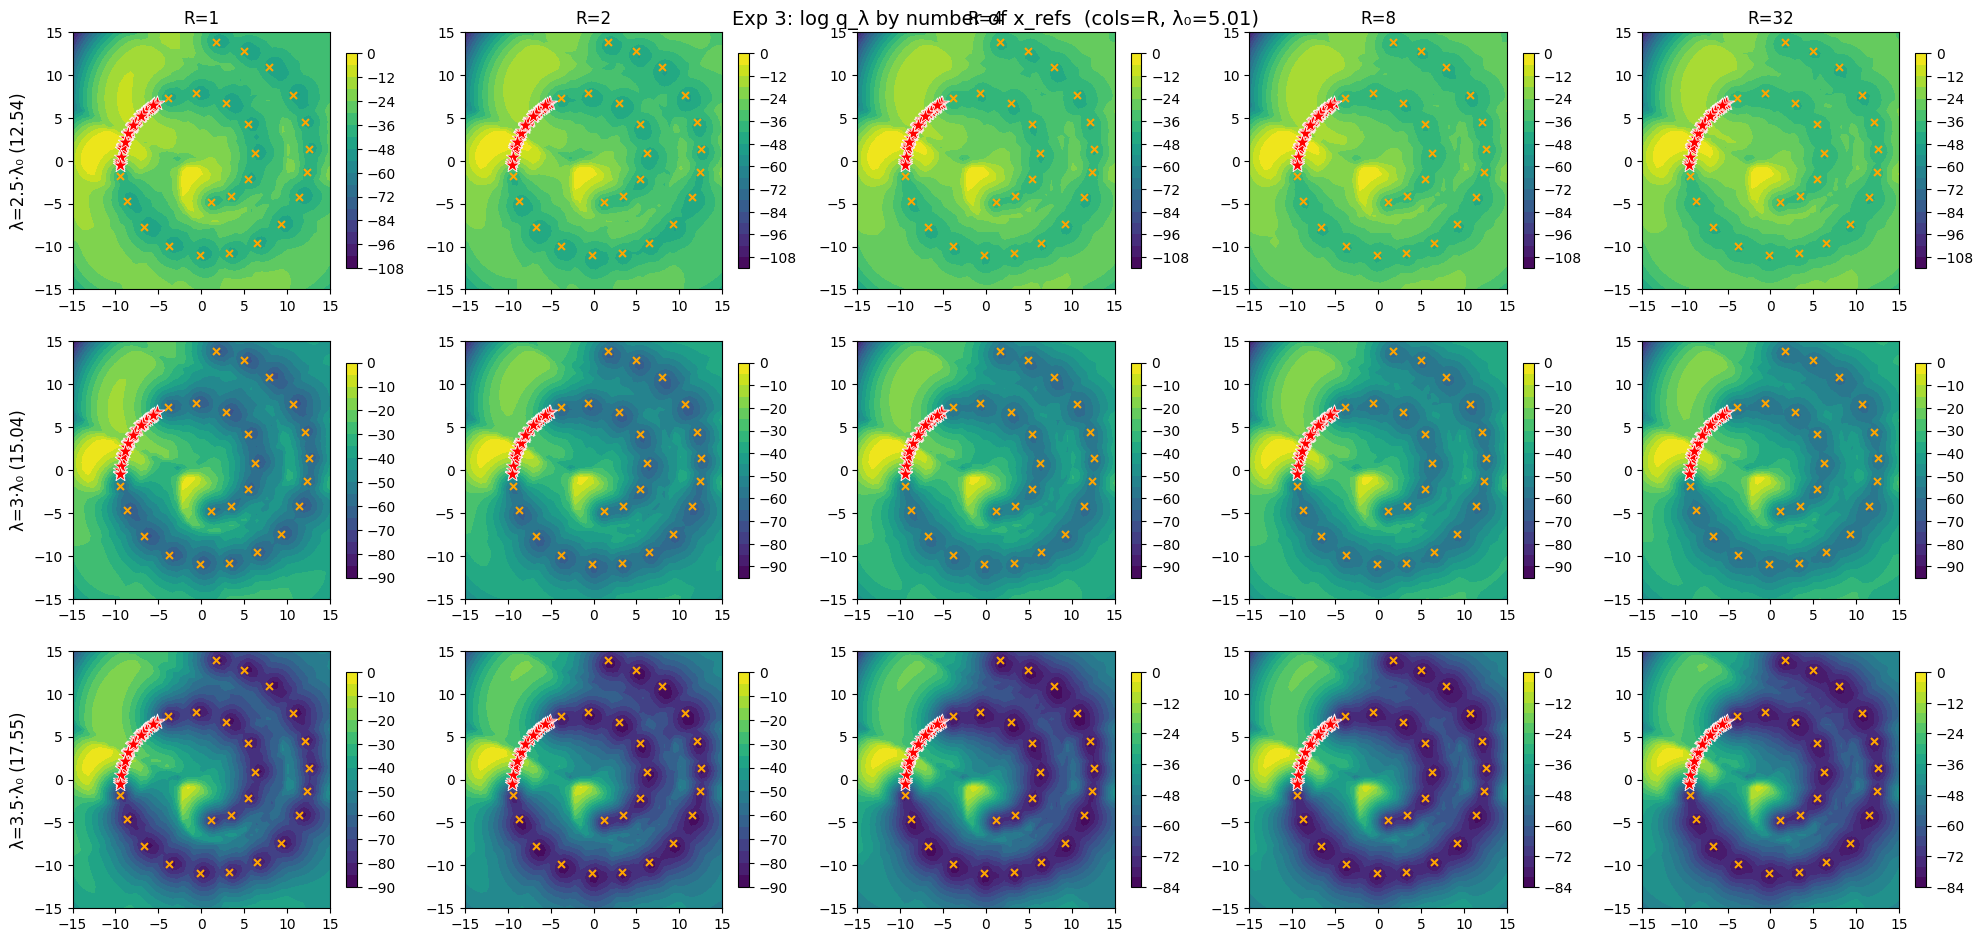

In [13]:
# Exp 3a (plot): 3x5 grid of log q_λ. rows = λ (multiples of λ₀), cols = number of refs R.
fig, _ = lambda_sweep(
    log_p_grid_roll2, exp3_expected_dists, cell_area, XX, YY,
    lambda0=LAMBDA_0, multipliers=LAMBDA_MULTS,
    field_labels=[f"R={r}" for r in EXP3_NREFS],
    row_labels=[f"λ={m:g}·λ₀ ({m*LAMBDA_0:.2f})" for m in LAMBDA_MULTS],
    marked=MEANS, missing=MISSING, panel_w=4, panel_h=3.2,
)
fig.suptitle(f"Exp 3: log q_λ by number of x_refs  (cols=R, λ₀={LAMBDA_0:.2f})", fontsize=14)
plt.show()

**Why few references suffice.** Write the marginal score $s_\gamma(x)\equiv\nabla\log p_{Y_\gamma}(\gamma x+W)$,
and $Z_\gamma=\log\frac{p_{Y_\gamma}(\gamma x'+W)}{p_{Y_\gamma}(\gamma x+W)}$, $\alpha=1/d$. Start from the
generalized-$f$ IEM (Def. 2, as in `generalized_global_iem.py`):

$$D^2_{\text{IEM},f}(x',x)=\int_0^\infty \mathbb{E}_W\!\Big[\,f'(\alpha Z_\gamma)^2\;\|s_\gamma(x')-s_\gamma(x)\|^2\,\Big]\,d\gamma$$

Expand the squared norm:

$$\|s_\gamma(x')-s_\gamma(x)\|^2=\|s_\gamma(x)\|^2+\|s_\gamma(x')\|^2-2\,\langle s_\gamma(x'),\,s_\gamma(x)\rangle$$

Substitute back (general $f$):

$$D^2_{\text{IEM},f}(x',x)=\int \mathbb{E}_W\!\Big[\,f'(\alpha Z_\gamma)^2\big(\|s_\gamma(x)\|^2+\|s_\gamma(x')\|^2-2\langle s_\gamma(x'),s_\gamma(x)\rangle\big)\Big]d\gamma$$

The weight $f'(\alpha Z_\gamma)^2$ multiplies every term, and $Z_\gamma$ depends on **both** $x$ and $x'$ — so the
$\|s_\gamma(x)\|^2$ term is *not* reference-independent. No separation yet.

**Now take $f=$ identity** ($f'\equiv1\Rightarrow f'(\alpha Z_\gamma)^2=1$, the weight drops):

$$D^2_{\text{IEM}}(x',x)=\int \mathbb{E}_W\big[\,\|s_\gamma(x)\|^2+\|s_\gamma(x')\|^2-2\langle s_\gamma(x'),s_\gamma(x)\rangle\,\big]d\gamma$$

By linearity of $\int d\gamma$ and $\mathbb{E}_W$, split into three:

$$D^2_{\text{IEM}}(x',x)=\underbrace{\int\mathbb{E}_W\|s_\gamma(x)\|^2 d\gamma}_{\text{ref-independent }(x\text{ only})}\;+\;\underbrace{\int\mathbb{E}_W\|s_\gamma(x')\|^2 d\gamma}_{\text{const in }x}\;-\;2\underbrace{\int\mathbb{E}_W\langle s_\gamma(x'),s_\gamma(x)\rangle d\gamma}_{\text{cross term}}$$

As a function of the scored point $x$: term 1 is identical for every reference; term 2 is an $x$-constant
(removed by `grid_normalize`); only term 3 depends on $x'$. The tilt score averages the root over refs,

$$f(x)=\tfrac1R\sum_{r}\sqrt{D^2_{\text{IEM}}(x'_r,x)}\,,$$

so term 1 dominates the $x$-shape. The cross term is linear in $s_\gamma(x')$: its $R$-average is $\langle\bar s_\gamma,s_\gamma(x)\rangle$ with 
$\bar s_\gamma=\tfrac1R\sum_r s_\gamma(x'r)\to\mathbb{E}{x'}[s_\gamma(x')]$ at the Monte-Carlo rate $\operatorname{Cov}{x'\sim p}[s\gamma]/R$. So 
convergence is set by how much $s_\gamma(x')$ varies across references — i.e. by the score's sensitivity to the clean point, which the 
second-order Tweedie identity (Gaussian noising, any $p$) gives in closed form:
$$\frac{\partial s_\gamma}{\partial x'} = \gamma\,\frac{\partial s_\gamma}{\partial y}=\gamma\,\operatorname{Cov}[X\mid Y_\gamma{=}y]-I.$$
The controlling quantity is the denoiser posterior covariance $\operatorname{Cov}[X\mid Y_\gamma{=}y]$ (the model's uncertainty about the clean 
point given the noisy $y$):

- small $\gamma$ (heavy noise): the posterior reverts to the prior and $\gamma\operatorname{Cov}\to 0$, so $\partial s_\gamma/\partial x'\to -I$ 
    and $s_\gamma(x')\approx -x' -W/\gamma$ (the $-W/\gamma$ is huge but ref-independent), thus $\operatorname{Var}_{x'}(s_\gamma)\to\operatorname{Cov}[\text{data}]$. Refs matter most here.
- large $\gamma$ (light noise): the posterior sharpens, $\gamma\operatorname{Cov}\to I$ cancels the $-I$, so $\partial s_\gamma/\partial x'\to 0$ 
    and $\operatorname{Var}_{x'}(s_\gamma)\to 0$. Refs become irrelevant.

The spread thus **decreases** with $\gamma$, and the adopted window $[3.83,1024]$ sits on the low/decaying side, so the cross term needs very few refs there.
Hence $R=1$ is already reasonable (single-anchor cross term). $R\geq4$ is balanced and stable. *(The diagnostic below plots this spread vs $\gamma$.)*

**Caveat:** the separation used $f'\equiv1$. For $f\neq$ identity (e.g. $f=$ squared, Exp 3b) the weight
$f'(\alpha Z_\gamma)^2$ couples $x$ and $x'$, so term 1 is no longer reference-independent and this argument need not hold.

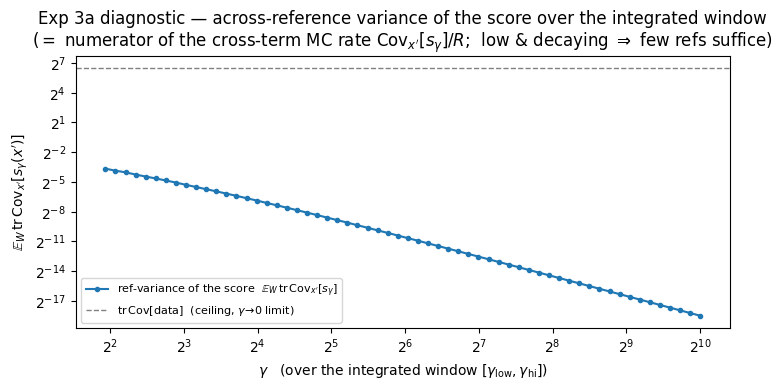

In [14]:
# Exp 3a diagnostic: across-reference variance of the score vector s_γ(x'), vs γ.
# tr Cov_{x'~p}[s_γ(x')] is the numerator of the cross-term's MC rate (Cov/R); small & decaying => few refs suffice.
# Swept over the INTEGRATED window [GAMMA_LO, GAMMA_HI] — the regime the measure actually uses.
def marginal_score(y, gamma):                       # s_γ(y) = ∇_y log p_Yγ(y), via autograd through log_p_Y
    log_p_Y = p_roll2.log_p_Y
    assert log_p_Y is not None, "p_roll2 needs log_p_Y for the score diagnostic"
    yy = y.detach().clone().requires_grad_(True)
    return torch.autograd.grad(log_p_Y(yy, gamma).sum(), yy)[0].detach()

torch.manual_seed(0)
gammas_diag = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), 60, base=2, dtype=dtype)   # integrated window
n_eps_diag, R = 128, x_refs.shape[0]
spread = []
for g in gammas_diag:
    W = torch.sqrt(g) * torch.randn(n_eps_diag, 1, 2, dtype=dtype)     # W ~ N(0, γ I)
    y = g * x_refs.view(1, R, 2) + W                                   # y = γ x' + W   (eps, R, d)
    s = marginal_score(y.reshape(-1, 2), g).reshape(n_eps_diag, R, 2)
    spread.append(s.var(dim=1, unbiased=False).sum(-1).mean().item())  # E_W [ tr Cov_{x'} s_γ ]
spread = torch.tensor(spread)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.loglog(gammas_diag, spread, base=2, marker='o', ms=3,
          label=r"ref-variance of the score  $\mathbb{E}_W\,\mathrm{tr}\,\mathrm{Cov}_{x'}[s_\gamma]$")
ax.axhline(x_refs.var(0, unbiased=False).sum().item(), ls='--', c='gray', lw=1,
           label=r"$\mathrm{tr}\,\mathrm{Cov}[\mathrm{data}]$  (ceiling, $\gamma\!\to\!0$ limit)")
ax.set_xlabel(r"$\gamma$   (over the integrated window $[\gamma_{\mathrm{low}},\gamma_{\mathrm{hi}}]$)")
ax.set_ylabel(r"$\mathbb{E}_W\,\mathrm{tr}\,\mathrm{Cov}_{x'}[s_\gamma(x')]$")
ax.set_title("Exp 3a diagnostic — across-reference variance of the score over the integrated window\n"
             r"($=$ numerator of the cross-term MC rate $\mathrm{Cov}_{x'}[s_\gamma]/R$;  low & decaying $\Rightarrow$ few refs suffice)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [15]:
# Exp 3a (choose R): top-weighted rank stability of the tilt f(x). Self-contained, ground-truth-free, no plot.
# f(x_k) = mean_m D_IEM(x'_m, x_k): a probe's expected distance to the refs = its creativity reward.
# The tilt exp(λf) acts most on HIGH-f probes, so we use weighted Kendall's τ (hyperbolic 1/(rank+1) weights):
# disagreements among top-ranked probes count heavily, low ones barely -> no hard top-k boundary, smooth curve.
# Stop on a PLATEAU that is also HIGH: τ_w gain per doubling < EPS for two consecutive steps AND τ_w >= TAU_FLOOR.
# (The double guard rejects single MC-noise dips and low-but-flat stretches.)
# Probes are sampled from p (disjoint from refs) -> the high-d recipe; certifies on-manifold stability.
from scipy.stats import weightedtau

EXP3_RSWEEP = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
M_refs    = 2 * max(EXP3_RSWEEP)                                  # pool large enough for the 2R sweep
EPS       = 0.015                                                 # plateau tol: τ_w gain per doubling below this = flat
TAU_FLOOR = 0.95                                                  # a plateau only counts once the ranking is this stable
x_probes_R = p_roll2.sample(300, seed=7)                          # probes ~ p (disjoint draw from refs)
x_refs_R   = p_roll2.sample(M_refs, seed=123)                     # reference pool ~ p
D_expR = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS,
                                      f_type=IEMFType.IDENTITY)
pairwise_R = D_expR.pairwise(x_probes_R, x_refs_R)                # (K_probes, M_refs), computed once
print(f"pairwise: {pairwise_R.shape[0]} probes x {M_refs} refs; sweeping R in {EXP3_RSWEEP}")

def wtau(fa, fb):                                                 # weighted Kendall τ; weight on HIGH-f probes (verified)
    return weightedtau(fa.cpu().numpy(), fb.cpu().numpy())[0]     # scipy is CPU/NumPy-only

gen = torch.Generator(device=default_device()).manual_seed(0)     # match pairwise_R's device for indexing
chosen_R, prev_tau, flat_run, flat_start = None, None, 0, None
print(f"{'R':>4}  {'weighted-τ':>12}  {'gain vs prev':>12}")
for R in EXP3_RSWEEP:
    t = []
    for _ in range(20):                                           # average over random reference draws
        perm = torch.randperm(M_refs, generator=gen)
        fR  = pairwise_R[:, perm[:R]].mean(dim=1)                 # R refs
        f2R = pairwise_R[:, perm[:2 * R]].mean(dim=1)             # nested 2R refs
        t.append(wtau(fR, f2R))                                   # does doubling R change the top-weighted ranking?
    t_mean = torch.tensor(t).mean().item()
    gain = None if prev_tau is None else t_mean - prev_tau       # marginal gain from the previous (halved) R
    print(f"{R:>4}  {t_mean:>12.4f}  {('—' if gain is None else f'{gain:+.4f}'):>12}")

    qualifying = gain is not None and gain < EPS and t_mean >= TAU_FLOOR  # flat AND already high
    if qualifying:
        if flat_run == 0:
            flat_start = R // 2                                  # this flat doubling means R/2 was already ~ as good
        flat_run += 1
        if chosen_R is None and flat_run >= 2:                   # two consecutive plateau steps (guards a noise dip)
            chosen_R = flat_start                                # smallest R confirmed to sit on the plateau
    else:
        flat_run = 0                                             # any real gain (or still-low τ) resets the run
    prev_tau = t_mean

if chosen_R is not None:
    print(f"chosen R = {chosen_R}  (plateau: τ_w >= {TAU_FLOOR} and gain < {EPS} for two consecutive doublings)")
else:
    print(f"no high plateau in the sweep (τ_w < {TAU_FLOOR} or still rising by >= {EPS}); extend the sweep / enlarge M")

pairwise: 300 probes x 1024 refs; sweeping R in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
   R    weighted-τ  gain vs prev
   1        0.7870             —
   2        0.8410       +0.0540
   4        0.8801       +0.0391
   8        0.9147       +0.0346
  16        0.9465       +0.0317
  32        0.9548       +0.0083
  64        0.9722       +0.0174
 128        0.9772       +0.0051
 256        0.9822       +0.0050
 512        0.9881       +0.0059
chosen R = 64  (plateau: τ_w >= 0.95 and gain < 0.015 for two consecutive doublings)


- **Conclusion 3a (choosing $R$).** With $f=$ identity the IEM splits into a reference-independent term (sets the $x$-shape, $\int\mathbb{E}_W\|s_\gamma(x)\|^2 d\gamma$) + an $x$-constant ($\int\mathbb{E}_W\|s_\gamma(x')\|^2 d\gamma$, removed by `grid_normalize`) + a cross term carrying all the $x'$-dependence. The cross term's reference-error is the MC rate $\operatorname{tr}\operatorname{Cov}_{x'}[s_\gamma]/R$, which the diagnostic above shows is small and **decays with $\gamma$** (window on the decaying side). Because that noise lands mostly on the normalization-removed constant, the tilt-relevant **ranking** of $f(x)$ converges faster than its magnitude — so we certify the *ranking*, not the value.

- **Sizing the pool with $\rho$.** In higher dimensions, could use the ratio $\rho=\int\operatorname{tr}\operatorname{Cov}_{x'}[s_\gamma]\,d\gamma / \int\mathbb{E}\|s_\gamma\|^2 d\gamma$ to estimate how hard it is to select a reference set, and how big should it be. $\rho\lesssim1$ easy (small $M$; here $\rho\approx0.76$), $\rho\gg1$ reference-hungry (large $M$). $\rho$ does **not** give $R$ directly (a value-accuracy quantity; the ranking is what matters), and it scales with the score's variability across the data manifold, not with $d$ per se.

- **In practice**, when moving to high-dimensional data, smartly choosing the reference point might allow to use a much smaller reference set while calculating $\mathbb E_{x' \sim p}[IEM(x,x')]$ for a given x. See creativity-measure/refset/ for initial implementations of `random_refs` (randomly samples from p, unbiased for $\mathbb E_{x' \sim p}[IEM(x,x')]$), `fps` (highly biased for $\mathbb E_{x' \sim p}[IEM(x,x')]$), and `weighted_fps` (asymptotically consistent for $\mathbb E_{x' \sim p}[IEM(x,x')]$). Currently uses Weighted Kendall's $\tau$ (targeting $\tau_w(f_R, f_{2R})$) for the for the termination criterion to estimate the *rank stability* achieved by a given reference set.

In [16]:
# COMPUTE: run the three refset selectors (auto-R), cache refs + grid scores for the plot cell.
import time
from typing import Any
from refset import RandomRefs, FPSRefs, WeightedFPSRefs

D_select = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=6, f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

common: dict[str, Any] = dict(seed=0, fallback="best", auto_r_draws=4, probe_size=64)

selectors = {
    "RandomRefs\n(i.i.d. ~ p, uniform w)":
        RandomRefs(p_roll2, distance=D_select,
                   auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128), tau_target=0.95, **common),
    "FPSRefs\n(max-min coverage)":
        FPSRefs(p_roll2, distance=D_select, pool_size=300,
                auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128), tau_target=0.88, **common),
    "WeightedFPSRefs\n(Voronoi inverse-density w)":
        WeightedFPSRefs(p_roll2, distance=D_select, pool_size=300, points_per_cell=16,
                        auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128), tau_target=0.95, **common),
}

results: dict[str, dict[str, Any]] = {}
print(f"{'algorithm':40s}  {'auto-R':>6}  {'τ@R':>6}  {'cleared?':>8}  {'time':>8}")
for name, sel in selectors.items():
    t0 = time.perf_counter()
    refs = sel.select()                                           # R=None -> auto-choose R from auto_r_grid (τ-level rule)
    R = refs.shape[0]
    pw = D_refset.pairwise(grid_points_roll2, refs)
    f_grid = sel._f_from_pairwise(pw, R, draw=0)
    dt = time.perf_counter() - t0

    hist = sel.tau_history
    tau_at_R = next((t for r, t in hist if r == R), float("nan"))
    cleared = tau_at_R >= sel.tau_target
    results[name] = dict(refs=refs.cpu().numpy(), f_grid=f_grid, R=R,
                         tau_history=hist, tau_target=sel.tau_target, cleared=cleared, dt=dt)
    print(f"{name.replace(chr(10), ' '):40s}  {R:6d}  {tau_at_R:6.3f}  {str(cleared):>8}  {dt:7.1f}s")

# Per-selector convergence detail: did it converge, or fall back to the τ ceiling?
print("\nτ sweep (R, τ) per selector  [* = cleared tau_target]:")
for name, sel in selectors.items():
    tgt = sel.tau_target
    pretty = "  ".join(f"{r}:{t:.2f}{'*' if t >= tgt else ''}" for r, t in sel.tau_history)
    flag = "converged" if results[name]["cleared"] else f"NOT cleared (fallback to τ-ceiling R={results[name]['R']})"
    print(f"  {name.replace(chr(10),' '):40s} target={tgt:.2f}  [{pretty}]  -> {flag}")

algorithm                                 auto-R     τ@R  cleared?      time
RandomRefs (i.i.d. ~ p, uniform w)           128   0.954      True    283.7s
FPSRefs (max-min coverage)                    16   0.935      True     68.0s
WeightedFPSRefs (Voronoi inverse-density w)     128   0.952      True    423.9s

τ sweep (R, τ) per selector  [* = cleared tau_target]:
  RandomRefs (i.i.d. ~ p, uniform w)       target=0.95  [1:0.71  2:0.86  4:0.84  8:0.88  16:0.91  32:0.88  64:0.94  128:0.95*]  -> converged
  FPSRefs (max-min coverage)               target=0.88  [1:0.38  2:0.04  4:0.64  8:0.69  16:0.93*]  -> converged
  WeightedFPSRefs (Voronoi inverse-density w) target=0.95  [1:0.95  2:0.79  4:0.79  8:0.83  16:0.94  32:0.94  64:0.94  128:0.95*]  -> converged


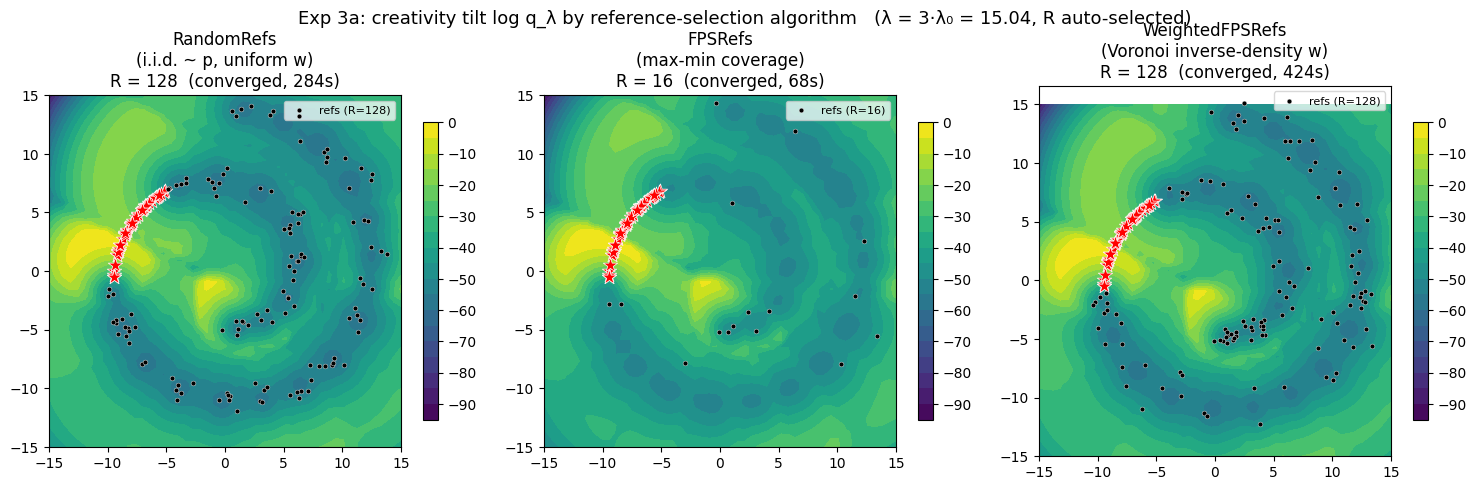

In [17]:
LAMBDA = 3.0 * LAMBDA_0
names = list(results)
fig, _ = lambda_sweep(
    log_p_grid_roll2, [results[n]["f_grid"] for n in names], cell_area, XX, YY,
    lambdas=LAMBDA,
    panel_titles=[
        f"{n}\nR = {results[n]['R']}  "
        f"({'converged' if results[n]['cleared'] else 'τ-ceiling (fallback)'}, {results[n]['dt']:.0f}s)"
        for n in names
    ],
    refs=[results[n]["refs"] for n in names],
    missing=MISSING, ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Exp 3a: creativity tilt log q_λ by reference-selection algorithm   "
             f"(λ = 3·λ₀ = {LAMBDA:.2f}, R auto-selected)", fontsize=13, y=1.05)
plt.show()

- The non-weighted FPSRefs converged too early.
- RandomRegs converged for a reaonable R of 64, while the WeightedFPSRefs converged for a higher R value. This is againt my ininial assessment.

    Should perform the comparison again later for higher dimensional data.
    
    Might need to choose a different termination criterion since the current WeightedFPSRefs calcualted the weights for every R (costly). Should consider using the biased-but-fast-to-converge (in runtime terms) termination criterion of FPSRef, and calculate the weights once after R's convergence.

### Exp 3b — number of x_refs, with f=squared

Exp 3a showed near-instant R-convergence, but the derivation's reference-independence step used $f'\equiv1$.
For $f=$ squared the integrand carries the weight $f'(\alpha Z_\gamma)^2=(2\alpha Z_\gamma)^2$, and $Z_\gamma$
depends on **both** $x$ and $x'$ — so term 1 is no longer reference-independent. Same sweep `R∈{1,2,4,8,32}`,
self-calibrated $\lambda_0$ for *this* $f$: does the fast convergence survive? (Note: $f=$ squared is also the
one Exp 4 flags as an improper tilt, so the panels may show that pattern regardless of $R$.)

In [18]:
# Exp 3b (compute): Exp-3a ref sweep, but f=squared. Reuse x_refs_big & EXP3_NREFS for an apples-to-apples comparison.
# f=squared has f'(αZ)²=(2αZ)², which couples x and x' through Z_γ, so refit λ₀ for THIS distance.
D_exp3b = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS, f_type=IEMFType.SQUARED)
pairwise_big_sq = D_exp3b.pairwise(grid_points_roll2, x_refs_big)        # (G, max R), one pass
f_refs_sq   = expected_distance(D_exp3b, x_refs, x_refs)                 # self-calibrate λ₀ for f=squared
LAMBDA_0_SQ = (p_roll2.log_p_X(x_refs).std() / f_refs_sq.std()).item()
exp3b_expected_dists = [pairwise_big_sq[:, :n].mean(dim=1) for n in EXP3_NREFS]
print(f"f=squared: λ₀_sq={LAMBDA_0_SQ:.3g}; ref counts: {EXP3_NREFS}")

f=squared: λ₀_sq=2.13; ref counts: [1, 2, 4, 8, 32]


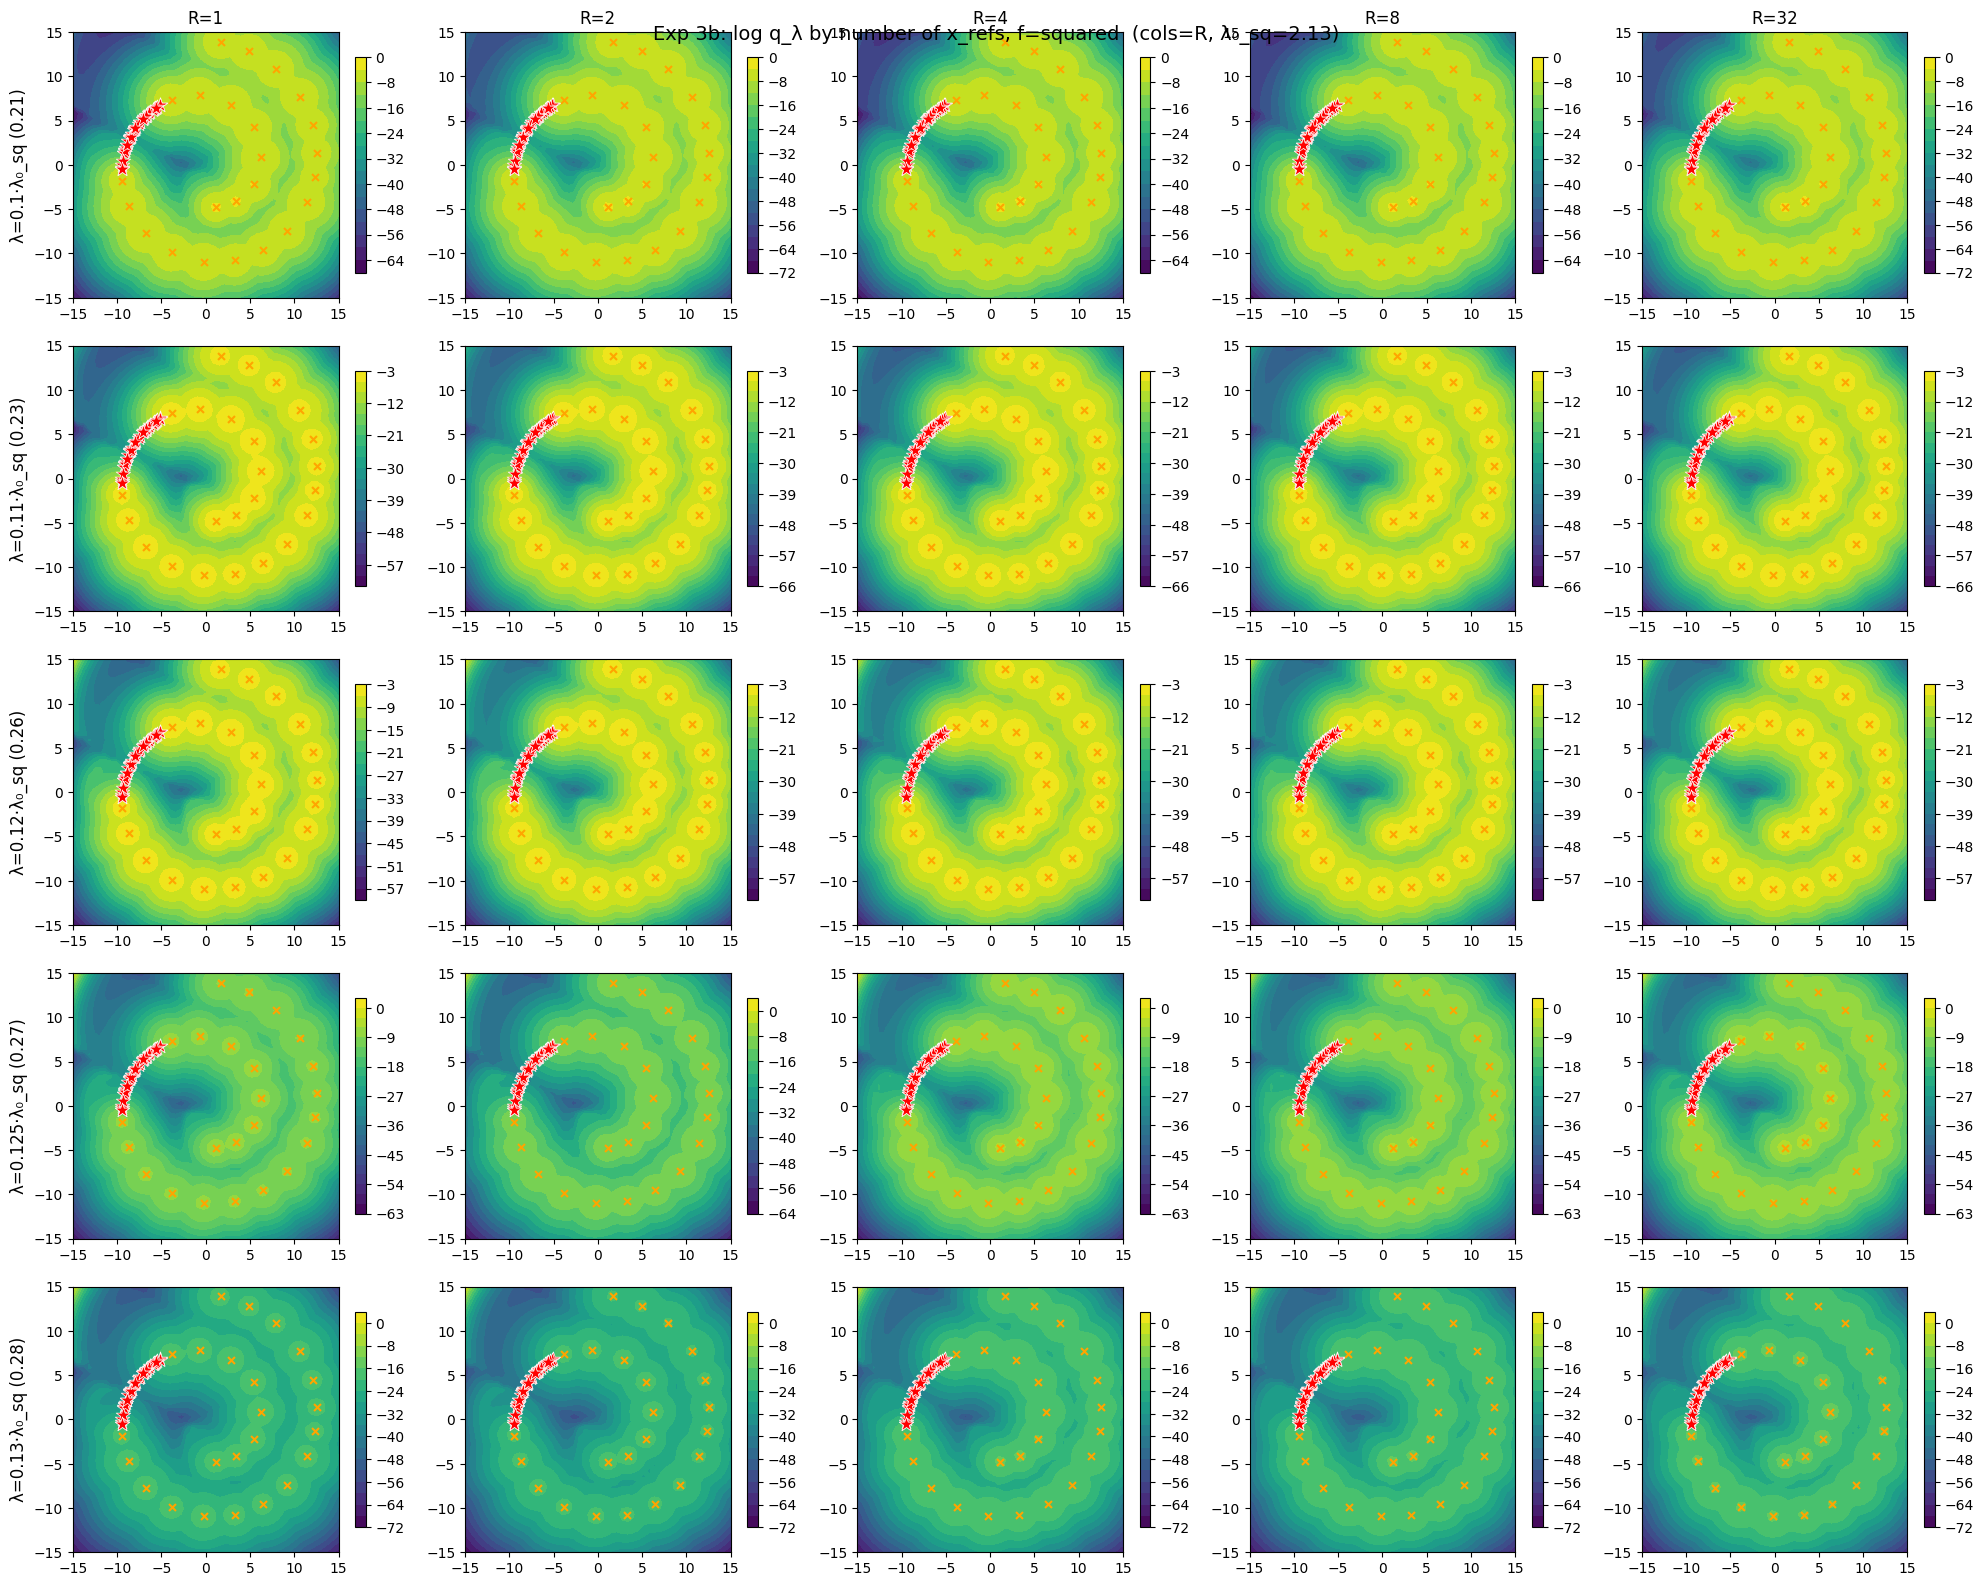

In [19]:
# Exp 3b (plot): 3x5 grid of log q_λ, f=squared. rows = λ multiples of λ₀_sq, cols = R.
LAMBDA_MULTS_SQ = [0.1, 0.11, 0.12, 0.125, 0.13]
fig, _ = lambda_sweep(
    log_p_grid_roll2, exp3b_expected_dists, cell_area, XX, YY,
    lambda0=LAMBDA_0_SQ, multipliers=LAMBDA_MULTS_SQ,
    field_labels=[f"R={r}" for r in EXP3_NREFS],
    row_labels=[f"λ={m:g}·λ₀_sq ({m*LAMBDA_0_SQ:.2f})" for m in LAMBDA_MULTS_SQ],
    marked=MEANS, missing=MISSING, panel_w=4, panel_h=3.2,
)
fig.suptitle(f"Exp 3b: log q_λ by number of x_refs, f=squared  (cols=R, λ₀_sq={LAMBDA_0_SQ:.2f})", fontsize=14)
plt.show()

The results show that generalized global IEM with f_squared doesn't fit a density $p$ that is modeled as a GMM, and therefore doesn't fit the Creativity Measure needs for for a GMM modeled data.

For a low enough $\lambda$, the tilt is negligable. For higher $\lambda$ values, The density is "pushed away". There is a clear value of $\lambda$ where the shift happens ($\lambda_{crit} \in [0.12, 0.125]$).

The integration window is **not** the problem here. $\gamma_{\text{low}} = 1/(C\cdot S)^2$ is not $f$-dependent, so the Exp1 conclusion about the window still holds.

**The problem is the weight**. With $f=$ squared the integrand acquires $f'(\alpha Z_\gamma)^2 = (2\alpha Z_\gamma)^2$, i.e. it becomes 

$$(2\alpha Z_\gamma)^2\,\big\|s_\gamma(x')-s_\gamma(x)\big\|^2\,d\gamma,\qquad Z_\gamma=\log\frac{p_{Y_\gamma}(\gamma x'+W)}{p_{Y_\gamma}(\gamma x+W)}$$

Whether this gives a valid Creativity Measure is a question about the **tails**:

$q_\lambda \propto p\,e^{\lambda f}$ is a valid density only if $Z_\lambda=\int p\,e^{\lambda f}<\infty$, which requires $\log q_{\text{unnorm}} = \log p + \lambda f \to -\infty$ as we leave the data. So it is a race, along any ray into the tail, between how fast $-\log p$ *decays* and how fast $\lambda f$ *grows*.

The diagnostic below runs that race on a clean radial ray and reads off the growth rates of each side, for the above swiss roll with a hole example.

tail exponents:  B(t)~t^1.97,  f_id~t^0.98,  f_sq~t^2.81  (gap f_sq-f_id=1.83 = injected Z~B factor)
squared margin B - λf_sq peaks at t≈13.8 (slopes equal) then falls monotonically -> log q rises -> improper; identity margin only rises


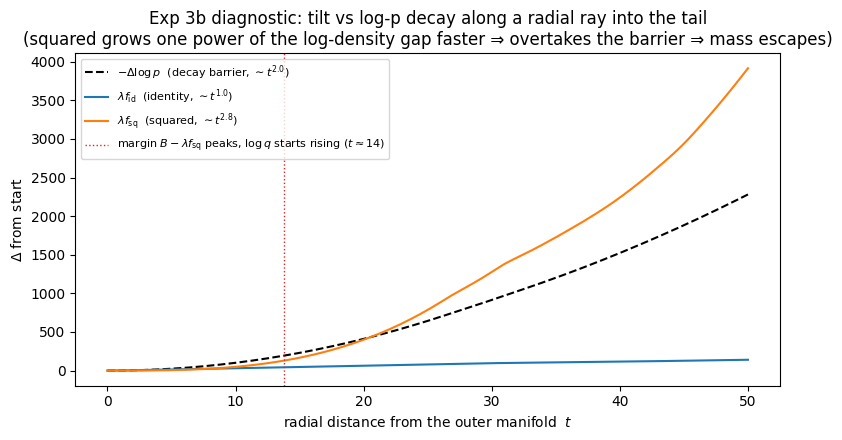

In [20]:
# Exp 3b diagnostic: tilt growth vs log-p decay along a ray leaving the manifold (why f=squared is improper).
# Start at the OUTERMOST reference and march radially outward (no arms beyond it -> log p decays cleanly into the
# deep tail). Compare the decay "barrier" -Δlog p against each tilt λf:
# a tilt that exceeds the barrier makes log q = log p + λf rise off-manifold => mass escapes.
center = MEANS.mean(0, keepdim=True)                    # spiral center
radii  = (x_refs - center).norm(dim=1)
p0     = x_refs[radii.argmax():radii.argmax() + 1]      # outermost ref -> clean exit, no arms beyond
direction = (p0 - center); direction = direction / direction.norm()   # radially outward
t = torch.linspace(0, 50, 200, dtype=dtype).view(-1, 1)      # far into the tail: expose the asymptotic crossover
ray = p0 + t * direction                                      # (T, 2)

D_id = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
logp = p_roll2.log_p_X(ray)
f_id = expected_distance(D_id,    ray, x_refs)          # identity score along the ray
f_sq = expected_distance(D_exp3b, ray, x_refs)          # squared score (reuse Exp 3b distance)

lam_id, lam_sq = 0.75 * LAMBDA_0, 0.12 * LAMBDA_0_SQ    # each f at its working strength
barrier = -(logp - logp[0])                             # how far log p has dropped (tilt must stay under this)
tt = t.flatten()

# Fit tail growth exponents (log-log slope on the clean outer part of the ray) so the rates are measured, not asserted.
def tail_exponent(tvals, yvals, t_min=4.0):
    m = (tvals > t_min) & (yvals > 0)
    lt, ly = torch.log(tvals[m]), torch.log(yvals[m])
    A = torch.stack([lt, torch.ones_like(lt)], dim=1)
    return torch.linalg.lstsq(A, ly.unsqueeze(1)).solution[0].item()

e_B  = tail_exponent(tt, barrier)
e_id = tail_exponent(tt, f_id - f_id[0])
e_sq = tail_exponent(tt, f_sq - f_sq[0])

# Normalizability margin g(t) = B - λf  (log q_unnorm = -g): rising => proper; a peak then fall => mass escapes past it.
g_id = barrier - lam_id * (f_id - f_id[0])
g_sq = barrier - lam_sq * (f_sq - f_sq[0])
peak_sq = tt[g_sq.argmax()].item()
print(f"tail exponents:  B(t)~t^{e_B:.2f},  f_id~t^{e_id:.2f},  f_sq~t^{e_sq:.2f}  "
      f"(gap f_sq-f_id={e_sq-e_id:.2f} = injected Z~B factor)")
print(f"squared margin B - λf_sq peaks at t≈{peak_sq:.1f} (slopes equal) then falls monotonically -> log q rises -> improper; identity margin only rises")

fig, ax = plt.subplots(figsize=(8, 4.5))
# .cpu() so matplotlib can convert these (CUDA tensors can't go straight to numpy); no-op on CPU.
ax.plot(tt.cpu(), barrier.cpu(),                   'k--', label=fr"$-\Delta\log p$  (decay barrier, $\sim t^{{{e_B:.1f}}}$)")
ax.plot(tt.cpu(), (lam_id * (f_id - f_id[0])).cpu(),     label=fr"$\lambda f_{{\mathrm{{id}}}}$  (identity, $\sim t^{{{e_id:.1f}}}$)")
ax.plot(tt.cpu(), (lam_sq * (f_sq - f_sq[0])).cpu(),     label=fr"$\lambda f_{{\mathrm{{sq}}}}$  (squared, $\sim t^{{{e_sq:.1f}}}$)")
ax.axvline(peak_sq, color='tab:red', ls=':', lw=1, label=fr"margin $B-\lambda f_{{\mathrm{{sq}}}}$ peaks, $\log q$ starts rising ($t\approx{peak_sq:.0f}$)")
ax.set_xlabel(r"radial distance from the outer manifold  $t$"); ax.set_ylabel(r"$\Delta$ from start")
ax.set_title("Exp 3b diagnostic: tilt vs log-p decay along a radial ray into the tail\n"
             "(squared grows one power of the log-density gap faster ⇒ overtakes the barrier ⇒ mass escapes)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**Reading the plot.** The dashed curve is the decay barrier $B(t)=-\Delta\log p$: how much room a tilt has before $\log q=\log p+\lambda f$ stops decaying. A log–log fit of the three curves on the clean outer part of the ray gives near-integer exponents (printed by the cell):

$$B(t)\sim t^{2},\qquad f_{\text{id}}(t)\sim t^{1},\qquad f_{\text{sq}}(t)\sim t^{3}.$$

**Why squared grows two powers faster — directly from its definition.** Both tilts share the score-difference factor. Writing it (via Tweedie) as a denoising error $s_\gamma(x)=x-\mathbb{E}[X\mid Y_\gamma]$, the difference between the two points is $s_\gamma(x')-s_\gamma(x)=(x'-x)-\big(\mathbb{E}[X\mid y']-\mathbb{E}[X\mid y]\big)$: the clean displacement $x'-x\sim t$, filtered by the denoiser. Its first-order slope is the second-order Tweedie factor $\partial s_\gamma/\partial x=\gamma\,\mathrm{Cov}[X\mid Y_\gamma]-I$.

Far out along the ray the posterior collapses onto a single Gaussian component, for which the posterior mean is *exactly linear* in $x$ with regression coefficient $\gamma\sigma^2/(\gamma\sigma^2+1)$, so $s_\gamma(x)=\big(x-\mu\big)/(\gamma\sigma^2+1)$ is proportional to the offset $x-\mu$ from the component mean, and $\|s_\gamma(x')-s_\gamma(x)\|\sim t/(\gamma\sigma^2+1)$.

This is linear in $t$ at **every** $\gamma$ — only the coefficient $1/(\gamma\sigma^2+1)$ changes: $\approx 1$ at the **heavy-noise / small-$\gamma$** end (slope $\to-I$, the score inherits the full displacement), $\to 0$ at large $\gamma$ (slope $\to 0$, the denoiser tracks $x$ and the difference is cancelled away). Since the integrand is $\sim t^2$ at every $\gamma$, integrating over the window and square-rooting gives $f_{\text{id}}\sim t$ regardless of the $\gamma$-weighting. Squared multiplies the integrand by $(2\alpha Z_\gamma)^2$, and $Z_\gamma$ *is* the log-density gap, which for a locally Gaussian $p$ grows like the barrier, $Z_\gamma\sim B(t)\sim t^2$; one factor survives the square-then-root, so

$$f_{\text{sq}}\;\sim\;\underbrace{t}_{f_{\text{id}}}\cdot\underbrace{t^{2}}_{Z_\gamma\,\sim\,B}\;=\;t^{3}.$$

The measured gap $f_{\text{sq}}-f_{\text{id}}\approx 2$ in the exponents is exactly this injected factor of $Z_\gamma\sim B$. **Squaring $f$ folds the log-density gap into the growth rate of the reward** — the reward now grows like (plausibility penalty) × (identity reward).

**Why that breaks normalizability — and why $\lambda$ can't fix it.** $Z_\lambda<\infty$ needs $\log q_{\text{unnorm}}=-(B-\lambda f)$ to fall off fast enough to integrate — which first of all requires $B(t)-\lambda f(t)\to+\infty$. With $B\sim t^b$, $f\sim t^a$, whether that holds is a contest of exponents, decided by $a$ vs $b$, not by the coefficient $\lambda$:

- $a<b$ (**identity**, $a=1<2$): $t^2-\lambda t\to+\infty$ for *every* $\lambda$. The decay reasserts itself and $q_\lambda\sim e^{-t^2}$ stays integrable - **proper for all $\lambda$**.
- $a=b$: borderline; the sign of $(1-\lambda)t^b$ flips at a finite critical $\lambda$.
- $a>b$ (**squared**, $a=3>2$): $t^2-\lambda t^3\to-\infty$ for *every* $\lambda>0$. $\log q$ rises without bound, $Z_\lambda=\infty$ - **improper for all $\lambda>0$**.

Shrinking $\lambda$ does not change $a$, it only pushes the crossover outward. The diagnostic shows this: $B-\lambda f_{\text{sq}}$ rises, peaks, and turns over (the printed turning point, $t \approx 14$), and smaller $\lambda$ just moves that peak farther out — never removes it. This is why, on the finite grid, $\lambda=0.12$ "survived" (but the tilt is insufficient) and $0.125$ did not: the blow-up sat past the grid edge. It is a *shape* failure (an exponent), not a *scale* one (a coefficient) — untunable.

**Semantic reading.** $f$ is a novelty reward added to log-plausibility $\log p$. For $q$ to favor novel-*but-plausible* points, plausibility must ultimately outrun novelty as we leave the data, so infinitely-far (zero-plausibility) points stay suppressed. Identity keeps novelty *below* plausibility's decay — a meaningful tilt; squared lets the reward outrun the penalty, so $q$ rewards pure novelty and leaks mass to the meaningless far tail. Squared is therefore **structurally improper for this construction, independent of the integration window** — which is why we keep $f=$ identity.

**Generalization to high dimensions (learned denoisers, image vectors).** The toy's exponents are partly GMM artifacts: the barrier $B(t)\sim t^2$ is just Gaussian tails, while a learned image density has whatever tail the network extrapolates.

What transfers is the mechanism, since it is definitional rather than Gaussian: $Z_\gamma$ *is* a log-density gap, so $Z_\gamma\sim B(t)$, and the squared weight gives, in any dimension,
$$f_{\text{sq}}\;\sim\;B(t)\cdot f_{\text{id}}\quad\Rightarrow\quad a_{\text{sq}}=a_{\text{id}}+b_Z,\quad b_Z\approx b\ \text{(for tails Gaussian-or-heavier)}.$$
Squaring folds the plausibility penalty into the reward's growth. Properness needs $a_{\text{sq}}<b$, i.e. $a_{\text{id}}<0$, which is impossible, since $f_{\text{id}}$ grows as we leave the data ($s_\gamma(x)=x-\mathbb{E}[X\mid Y_\gamma]$ keeps the raw $x$; a manifold-respecting denoiser projects $y$ back, so $s\sim x$ never vanishes). So whenever $f_{\text{id}}$ grows and $\log p$ decays, squared is improper.

**Bottom line.** To reliably obtain a *normalized* Creativity Measure, $f=$ identity is the safer choice in any dimension: it keeps the reward's growth below the log-density decay, so $q_\lambda$ stays integrable for every $\lambda$, and $\lambda$ can be used as a tuning parameter.

## Adopted settings — after Exp 3 (merged)

Adds **R = 32** references (an overkill, converged by $R \approx 4$, but cheap). 
Full setting carried into Exp 4 onward: window `C=0.75` (`γ_lo≈3.83`, `γ_hi=2¹⁰`), `N_γ=50`, `R=32`, `λ₀≈5.01`, rows `λ={2.5,3,3.5}·λ₀`.

In [21]:
# Merged adoption (Exp 1 + 2 + 3): window C=0.75, density N_γ=50, R=32 refs, matching λ₀.
# Used by Exp 4 onward.
S        = torch.sqrt(VARS).mean().item()   # per-component std (1a crossover scale)
C        = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2               # ≈ 3.83   (σ_max = 1/√γ_lo)
GAMMA_HI = 2.0 ** 10                        #          (σ_min = 1/√γ_hi)
N_GAMMA  = 50                               # Exp 2: converged on this window
N_REFS   = 32                               # Exp 3: converged by R≈4; 32 is overkill but cheap (MC margin)
LAMBDA_MULTS = [2.5, 3.0, 3.5]              # rows in following experiment grids = m · λ₀

# Adopted γ grid and the λ₀ self-calibrated on it (over the N_REFS adopted x_refs); fixed for Exp 4 onward.
GAMMAS   = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)
assert x_refs.shape[0] == N_REFS, f"x_refs has {x_refs.shape[0]} refs, expected N_REFS={N_REFS}"
_D0      = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
LAMBDA_0 = (p_roll2.log_p_X(x_refs).std() / expected_distance(_D0, x_refs, x_refs).std()).item()
print(f"Adopted (Exp 1+2+3): C={C}, γ_lo={GAMMA_LO:.3g}, γ_hi={GAMMA_HI:.0f}, N_γ={N_GAMMA}, "
      f"R={N_REFS}, λ₀={LAMBDA_0:.3g}; λ rows = {[round(m * LAMBDA_0, 2) for m in LAMBDA_MULTS]}")

Adopted (Exp 1+2+3): C=0.75, γ_lo=3.83, γ_hi=1024, N_γ=50, R=32, λ₀=5.01; λ rows = [12.54, 15.04, 17.55]


# Adopted Settings demonstration

## Guassians

In [22]:
D, N_TOTAL, RADIUS, SIGMA = 2, 12, 4.0, 0.3
angles = 2 * math.pi * torch.arange(N_TOTAL, dtype=dtype) / N_TOTAL
all_means = torch.stack([RADIUS * torch.cos(angles), RADIUS * torch.sin(angles)], dim=-1)
mask = torch.ones(N_TOTAL, dtype=torch.bool)
MEANS = all_means[mask]          # (K, 2) observed modes (hole removed)
K = MEANS.shape[0]
S2 = SIGMA ** 2
logK = math.log(K)

def log_pX(x):
    # Equal-weight isotropic GMM, pure tensor ops (vmap-safe)
    diff = x.unsqueeze(-2) - MEANS          # (..., K, 2)
    quad = diff.pow(2).sum(-1) / S2         # (..., K)
    logcomp = -0.5 * quad -0.5 * D * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    # Y = gamma*X + sqrt(gamma)*W; comp k ~ N(gamma*mu_k, (gamma^2*S2 + gamma)*I)
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS  # (..., K, 2)
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad -0.5 * D * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def ring_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_ring = Density(log_pX, log_pY, sample_fn=ring_sample, d=2)

# Grid and reference points
grid_points_ring, XX, YY, cell_area = make_grid((-6, 6), (-6, 6), grid_n=50, dtype=dtype)
log_p_grid_ring = p_ring.log_p_X(grid_points_ring)
x_refs = p_ring.sample(32, seed=123)
print(f"Grid: {grid_points_ring.shape[0]} points, cell_area={cell_area:.4f}; x_refs shape: {x_refs.shape}")

Grid: 2500 points, cell_area=0.0600; x_refs shape: torch.Size([32, 2])


In [23]:
# Gaussians — adopted setting (Exp 1+2+3) with RandomRefs auto-R; γ-window & λ₀ recalibrated to THIS density.
import time
from refset import RandomRefs

C, N_GAMMA = 0.75, 50
S        = SIGMA                                    # per-component std (γ-window scale)
GAMMA_LO = 1.0 / (C * S) ** 2
GAMMA_HI = 2.0 ** 10
GAMMAS_g = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)

D_select = GeneralizedGlobalIEMDistance(p_ring, GAMMAS_g, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_ring, GAMMAS_g, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_g = RandomRefs(p_ring, distance=D_select,
                   auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128), tau_target=0.95,
                   seed=0, fallback="best", auto_r_draws=4, probe_size=64)

t0 = time.perf_counter()
refs_g = sel_g.select()                             # R=None -> auto-choose R via the τ-level rule
dt = time.perf_counter() - t0
R_g = refs_g.shape[0]
print(f"Gaussians: RandomRefs auto-R = {R_g}  (refs generated in {dt:.1f}s)")

# Tilt over the grid + per-density λ₀, both via the public expected_distance helper (uniform-weight mean).
f_grid_g   = expected_distance(D_refset, grid_points_ring, refs_g)
LAMBDA_0_g = (p_ring.log_p_X(refs_g).std()
              / expected_distance(D_refset, refs_g, refs_g).std()).item()

print(f"  chosen params: γ=[{GAMMA_LO:.3g}, {GAMMA_HI:.0f}], N_γ={N_GAMMA}, R={R_g}, λ₀={LAMBDA_0_g:.3g}")

Gaussians: RandomRefs auto-R = 128  (refs generated in 58.2s)
  chosen params: γ=[19.8, 1024], N_γ=50, R=128, λ₀=3.42


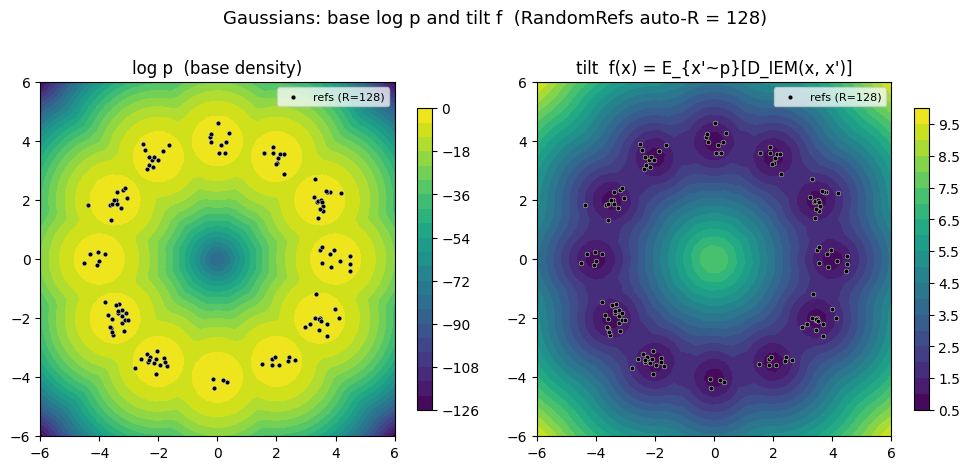

In [24]:
# Gaussians — components of log q_λ: (left) base log p,  (right) tilt f(x) = E_{x'~p}[D_IEM(x, x')].
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_ring, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_g)
plot_field(f_grid_g,        XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_g)
fig.suptitle(f"Gaussians: base log p and tilt f  (RandomRefs auto-R = {R_g})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

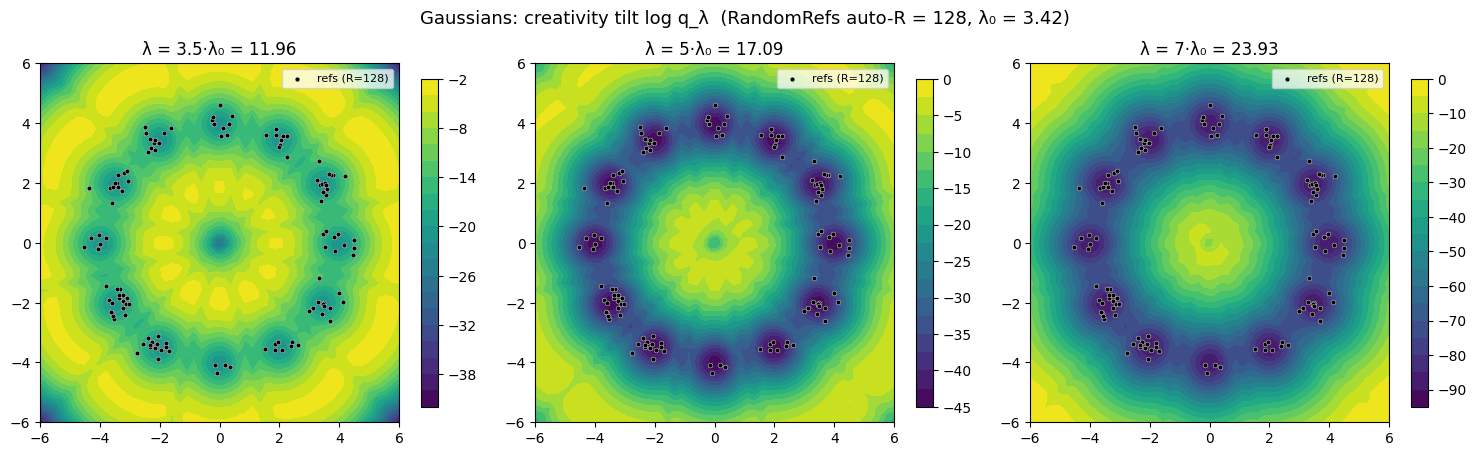

In [25]:
# Gaussians — log q_λ at λ = m·λ₀ for m ∈ {2.5, 3, 3.5} (per-density λ₀; RandomRefs auto-R).
LAMBDA_MULTS = [3.5, 5, 7]
fig, _ = lambda_sweep(
    log_p_grid_ring, f_grid_g, cell_area, XX, YY,
    lambda0=LAMBDA_0_g, multipliers=LAMBDA_MULTS,
    panel_titles=[f"λ = {m:g}·λ₀ = {m*LAMBDA_0_g:.2f}" for m in LAMBDA_MULTS],
    refs=refs_g, ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Gaussians: creativity tilt log q_λ  (RandomRefs auto-R = {R_g}, λ₀ = {LAMBDA_0_g:.2f})",
             fontsize=13, y=1.03)
plt.show()

## Gussians with a Hole

In [26]:
D, N_TOTAL, HOLE_IDX, RADIUS, SIGMA = 2, 12, 0, 4.0, 0.3
angles = 2 * math.pi * torch.arange(N_TOTAL, dtype=dtype) / N_TOTAL
all_means = torch.stack([RADIUS * torch.cos(angles), RADIUS * torch.sin(angles)], dim=-1)
mask = torch.ones(N_TOTAL, dtype=torch.bool)
mask[HOLE_IDX] = False
MEANS = all_means[mask]          # (K, 2) observed modes (hole removed)
K = MEANS.shape[0]
S2 = SIGMA ** 2
logK = math.log(K)

def log_pX(x):
    # Equal-weight isotropic GMM, pure tensor ops (vmap-safe)
    diff = x.unsqueeze(-2) - MEANS          # (..., K, 2)
    quad = diff.pow(2).sum(-1) / S2         # (..., K)
    logcomp = -0.5 * quad -0.5 * D * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    # Y = gamma*X + sqrt(gamma)*W; comp k ~ N(gamma*mu_k, (gamma^2*S2 + gamma)*I)
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS  # (..., K, 2)
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad -0.5 * D * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def ring_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_ring = Density(log_pX, log_pY, sample_fn=ring_sample, d=2)
print(f"Ring GMM: {K} observed modes (hole at index {HOLE_IDX}), radius={RADIUS}, sigma={SIGMA}")

# Grid and reference points
grid_points_ring, XX, YY, cell_area = make_grid((-6, 6), (-6, 6), grid_n=50, dtype=dtype)
log_p_grid_ring = p_ring.log_p_X(grid_points_ring)
x_refs = p_ring.sample(32, seed=123)
print(f"Grid: {grid_points_ring.shape[0]} points, cell_area={cell_area:.4f}; x_refs shape: {x_refs.shape}")

Ring GMM: 11 observed modes (hole at index 0), radius=4.0, sigma=0.3
Grid: 2500 points, cell_area=0.0600; x_refs shape: torch.Size([32, 2])


In [27]:
# Gaussians with a Hole — adopted setting (Exp 1+2+3) with RandomRefs auto-R; γ-window & λ₀ recalibrated to THIS density.
import time
from refset import RandomRefs

C, N_GAMMA = 0.75, 50
S        = SIGMA                                    # per-component std (γ-window scale)
GAMMA_LO = 1.0 / (C * S) ** 2
GAMMA_HI = 2.0 ** 10
GAMMAS_gh = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)

D_select = GeneralizedGlobalIEMDistance(p_ring, GAMMAS_gh, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_ring, GAMMAS_gh, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_gh = RandomRefs(p_ring, distance=D_select,
                    auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256), tau_target=0.95,
                    seed=0, fallback="best", auto_r_draws=4, probe_size=64)

t0 = time.perf_counter()
refs_gh = sel_gh.select()                           # R=None -> auto-choose R via the τ-level rule
dt = time.perf_counter() - t0
R_gh = refs_gh.shape[0]
print(f"Gaussians with a Hole: RandomRefs auto-R = {R_gh}  (refs generated in {dt:.1f}s)")

# Tilt over the grid + per-density λ₀, both via the public expected_distance helper (uniform-weight mean).
f_grid_gh   = expected_distance(D_refset, grid_points_ring, refs_gh)
LAMBDA_0_gh = (p_ring.log_p_X(refs_gh).std()
               / expected_distance(D_refset, refs_gh, refs_gh).std()).item()

print(f"  chosen params: γ=[{GAMMA_LO:.3g}, {GAMMA_HI:.0f}], N_γ={N_GAMMA}, R={R_gh}, λ₀={LAMBDA_0_gh:.3g}")

Gaussians with a Hole: RandomRefs auto-R = 128  (refs generated in 108.6s)
  chosen params: γ=[19.8, 1024], N_γ=50, R=128, λ₀=3.39


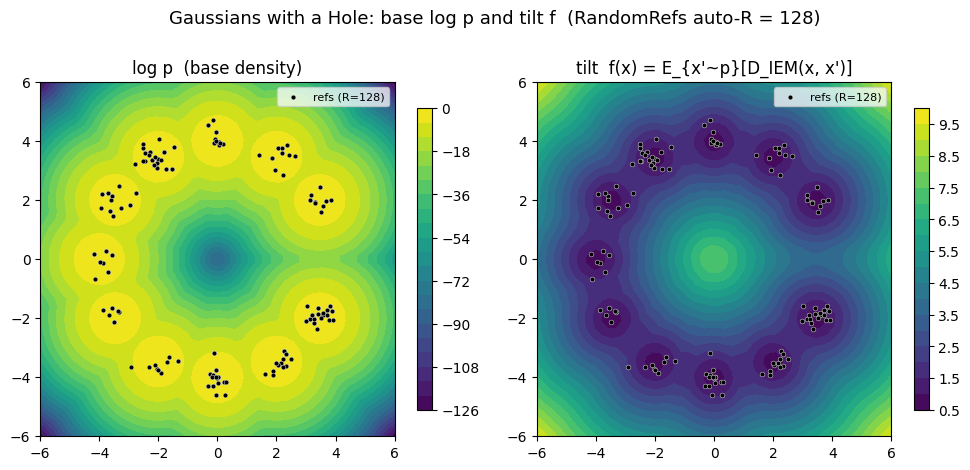

In [28]:
# Gaussians with a Hole — components of log q_λ: (left) base log p,  (right) tilt f(x) = E_{x'~p}[D_IEM(x, x')].
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_ring, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_gh)
plot_field(f_grid_gh,       XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_gh)
fig.suptitle(f"Gaussians with a Hole: base log p and tilt f  (RandomRefs auto-R = {R_gh})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

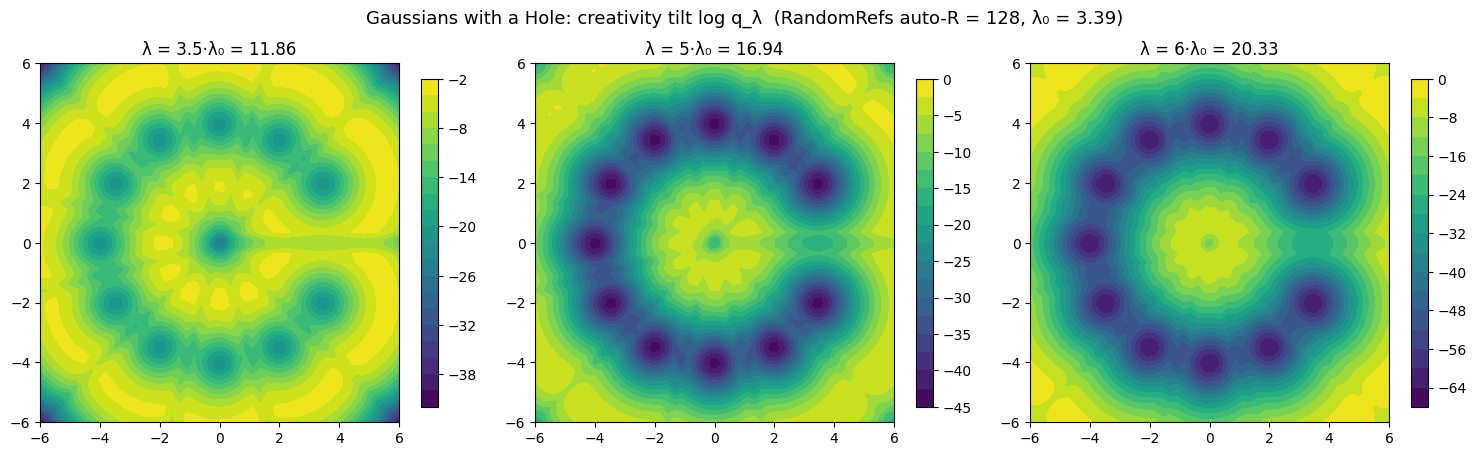

In [29]:
# Gaussians with a Hole — log q_λ at λ = m·λ₀ for m ∈ {2.5, 3, 3.5} (per-density λ₀; RandomRefs auto-R).
LAMBDA_MULTS = [3.5, 5, 6]
fig, _ = lambda_sweep(
    log_p_grid_ring, f_grid_gh, cell_area, XX, YY,
    lambda0=LAMBDA_0_gh, multipliers=LAMBDA_MULTS,
    panel_titles=[f"λ = {m:g}·λ₀ = {m*LAMBDA_0_gh:.2f}" for m in LAMBDA_MULTS],
    ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Gaussians with a Hole: creativity tilt log q_λ  (RandomRefs auto-R = {R_gh}, λ₀ = {LAMBDA_0_gh:.2f})",
             fontsize=13, y=1.03)
plt.show()

## Two Moons

In [30]:
K_PER_MOON = 16         # Gaussians per arc
SIGMA = 0.18            # component width (keep ≈ bead spacing: RADIUS*ARC/(K-1))
S2 = SIGMA ** 2
ARC = 0.5 * math.pi     # angular span of each arc: π = closed C-shape, smaller = more open/flatter
RADIUS = 3              # arc size; larger = longer arcs
H_SHIFT = 2             # horizontal offset of moon2 (0 = directly below moon1)
V_SHIFT = 0.0           # vertical distance between the two moons

t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
MEANS = torch.cat([moon1, moon2], dim=0)
K = MEANS.shape[0]
logK = math.log(K)
Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    logcomp = -0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
print(f"Two-moons GMM: {K} components ({K_PER_MOON}/moon), sigma={SIGMA}")

# Grid and reference points
grid_points_moons, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_moons = p_moons.log_p_X(grid_points_moons)
x_refs = p_moons.sample(32, seed=123)
print(f"Grid: {grid_points_moons.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Two-moons GMM: 32 components (16/moon), sigma=0.18
Grid: 2500 points, cell_area=0.1062; refs: torch.Size([32, 2])


In [31]:
# Two Moons — adopted setting (Exp 1+2+3) with RandomRefs auto-R; γ-window & λ₀ recalibrated to THIS density.
import time
from refset import RandomRefs

C, N_GAMMA = 0.75, 50
S        = SIGMA                                    # per-component std (γ-window scale)
GAMMA_LO = 1.0 / (C * S) ** 2
GAMMA_HI = 2.0 ** 10
GAMMAS_m = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)

D_select = GeneralizedGlobalIEMDistance(p_moons, GAMMAS_m, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_moons, GAMMAS_m, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_m = RandomRefs(p_moons, distance=D_select,
                   auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256), tau_target=0.95,
                   seed=0, fallback="best", auto_r_draws=4, probe_size=64)

t0 = time.perf_counter()
refs_m = sel_m.select()                             # R=None -> auto-choose R via the τ-level rule
dt = time.perf_counter() - t0
R_m = refs_m.shape[0]
print(f"Two Moons: RandomRefs auto-R = {R_m}  (refs generated in {dt:.1f}s)")

# Tilt over the grid + per-density λ₀, both via the public expected_distance helper (uniform-weight mean).
f_grid_m   = expected_distance(D_refset, grid_points_moons, refs_m)
LAMBDA_0_m = (p_moons.log_p_X(refs_m).std()
              / expected_distance(D_refset, refs_m, refs_m).std()).item()

print(f"  chosen params: γ=[{GAMMA_LO:.3g}, {GAMMA_HI:.0f}], N_γ={N_GAMMA}, R={R_m}, λ₀={LAMBDA_0_m:.3g}")

Two Moons: RandomRefs auto-R = 16  (refs generated in 136.3s)
  chosen params: γ=[54.9, 1024], N_γ=50, R=16, λ₀=2.61


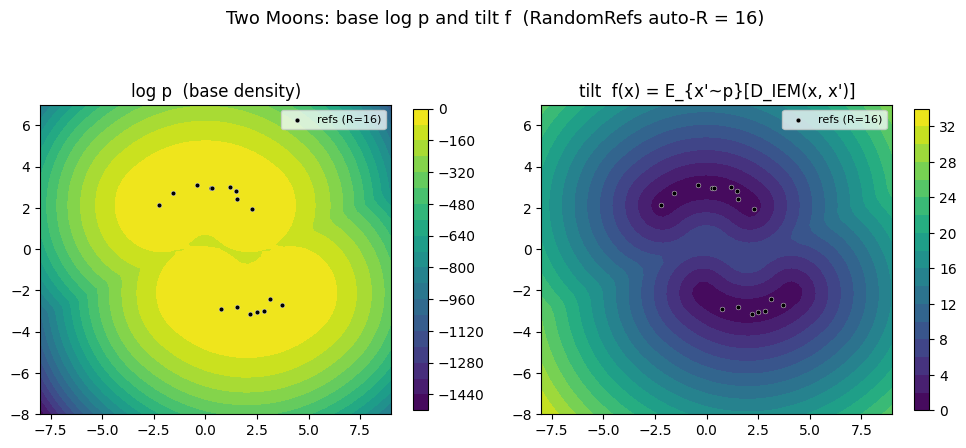

In [32]:
# Two Moons — components of log q_λ: (left) base log p,  (right) tilt f(x) = E_{x'~p}[D_IEM(x, x')].
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_moons, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_m)
plot_field(f_grid_m,         XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_m)
fig.suptitle(f"Two Moons: base log p and tilt f  (RandomRefs auto-R = {R_m})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

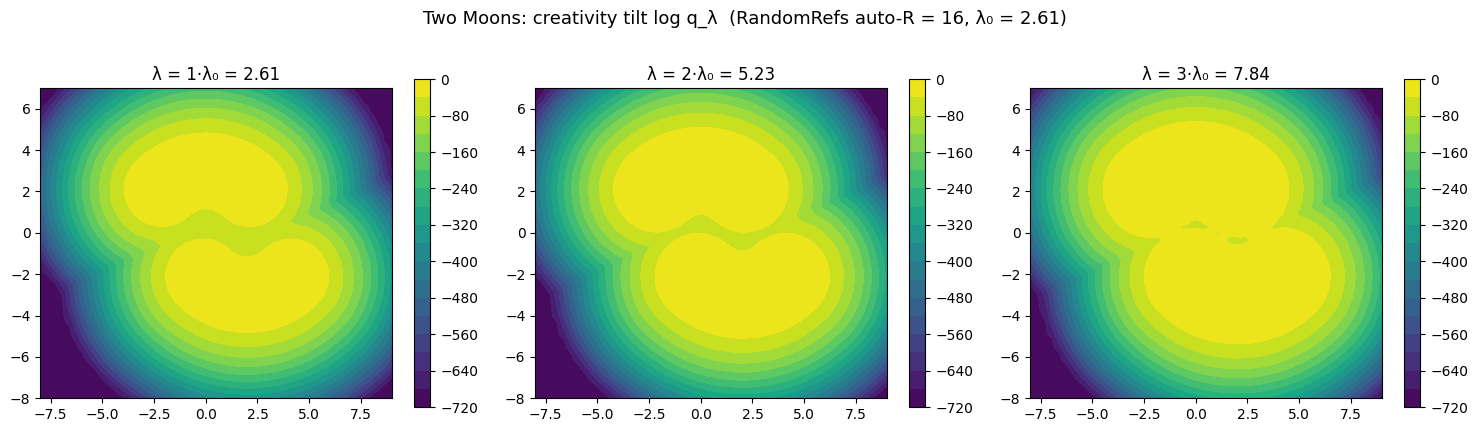

In [33]:
# Two Moons — log q_λ at λ = m·λ₀ for m ∈ {2.5, 3, 3.5} (per-density λ₀; RandomRefs auto-R).
LAMBDA_MULTS = [1, 2, 3]
fig, _ = lambda_sweep(
    log_p_grid_moons, f_grid_m, cell_area, XX, YY,
    lambda0=LAMBDA_0_m, multipliers=LAMBDA_MULTS,
    panel_titles=[f"λ = {m:g}·λ₀ = {m*LAMBDA_0_m:.2f}" for m in LAMBDA_MULTS],
    ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Two Moons: creativity tilt log q_λ  (RandomRefs auto-R = {R_m}, λ₀ = {LAMBDA_0_m:.2f})",
             fontsize=13, y=1.03)
plt.show()

## Two Moons with a hole

In [34]:
K_PER_MOON = 16                 # Gaussians per arc
SIGMA = 0.18                    # component width (keep ≈ bead spacing: RADIUS*ARC/(K-1))
S2 = SIGMA ** 2
ARC = 0.5 * math.pi             # angular span of each arc: π = closed C-shape, smaller = more open/flatter
RADIUS = 3                      # arc size; larger = longer arcs
H_SHIFT = 2                     # horizontal offset of moon2 (0 = directly below moon1)
V_SHIFT = 0.0                   # vertical distance between the two moons

HOLE_MOON = 1                   # 0 = upper moon, 1 = lower moon
HOLE_START, HOLE_END = 2, 11     # remove beads [HOLE_START, HOLE_END) from that arc

t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
all_means = torch.cat([moon1, moon2], dim=0)        # full set, before removal

# Build a mask that removes a contiguous slice of one arc
mask = torch.ones(all_means.shape[0], dtype=torch.bool)
offset = HOLE_MOON * K_PER_MOON                      # 0 for moon1, K_PER_MOON for moon2
mask[offset + HOLE_START : offset + HOLE_END] = False

MEANS = all_means[mask]          # kept components (used in the density)
MISSING = all_means[~mask]       # removed components (the hole) — for plotting
K = MEANS.shape[0]
logK = math.log(K)
Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    logcomp = -0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons2 = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
print(f"Two-moons GMM (hole): {K} kept components, "
      f"removed beads [{HOLE_START},{HOLE_END}) of moon {HOLE_MOON}, sigma={SIGMA}")

# Grid and reference points
grid_points_moons2, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_moons2 = p_moons2.log_p_X(grid_points_moons2)
x_refs = p_moons2.sample(32, seed=123)
print(f"Grid: {grid_points_moons2.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Two-moons GMM (hole): 23 kept components, removed beads [2,11) of moon 1, sigma=0.18
Grid: 2500 points, cell_area=0.1062; refs: torch.Size([32, 2])


In [35]:
# Two Moons with a hole — adopted setting (Exp 1+2+3) with RandomRefs auto-R; γ-window & λ₀ recalibrated to THIS density.
import time
from refset import RandomRefs

C, N_GAMMA = 0.75, 50
S        = SIGMA                                    # per-component std (γ-window scale)
GAMMA_LO = 1.0 / (C * S) ** 2
GAMMA_HI = 2.0 ** 10
GAMMAS_mh = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)

D_select = GeneralizedGlobalIEMDistance(p_moons2, GAMMAS_mh, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_moons2, GAMMAS_mh, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_mh = RandomRefs(p_moons2, distance=D_select,
                    auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256), tau_target=0.95,
                    seed=0, fallback="best", auto_r_draws=4, probe_size=64)

t0 = time.perf_counter()
refs_mh = sel_mh.select()                           # R=None -> auto-choose R via the τ-level rule
dt = time.perf_counter() - t0
R_mh = refs_mh.shape[0]
print(f"Two Moons with a hole: RandomRefs auto-R = {R_mh}  (refs generated in {dt:.1f}s)")

# Tilt over the grid + per-density λ₀, both via the public expected_distance helper (uniform-weight mean).
f_grid_mh   = expected_distance(D_refset, grid_points_moons2, refs_mh)
LAMBDA_0_mh = (p_moons2.log_p_X(refs_mh).std()
               / expected_distance(D_refset, refs_mh, refs_mh).std()).item()

print(f"  chosen params: γ=[{GAMMA_LO:.3g}, {GAMMA_HI:.0f}], N_γ={N_GAMMA}, R={R_mh}, λ₀={LAMBDA_0_mh:.3g}")

Two Moons with a hole: RandomRefs auto-R = 128  (refs generated in 125.5s)
  chosen params: γ=[54.9, 1024], N_γ=50, R=128, λ₀=3.01


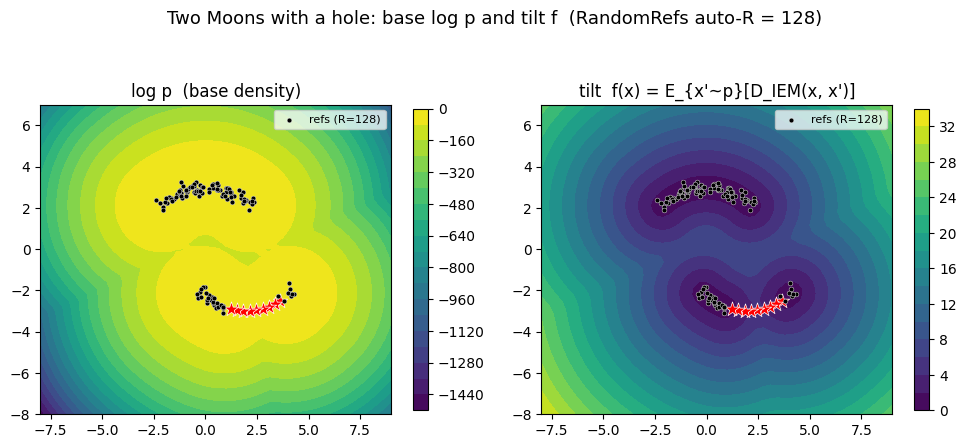

In [36]:
# Two Moons with a hole — components of log q_λ: (left) base log p,  (right) tilt f(x) = E_{x'~p}[D_IEM(x, x')].
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_moons2, XX, YY, ax=axes[0], title="log p  (base density)", missing=MISSING, refs=refs_mh)
plot_field(f_grid_mh,         XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", missing=MISSING, refs=refs_mh)
fig.suptitle(f"Two Moons with a hole: base log p and tilt f  (RandomRefs auto-R = {R_mh})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

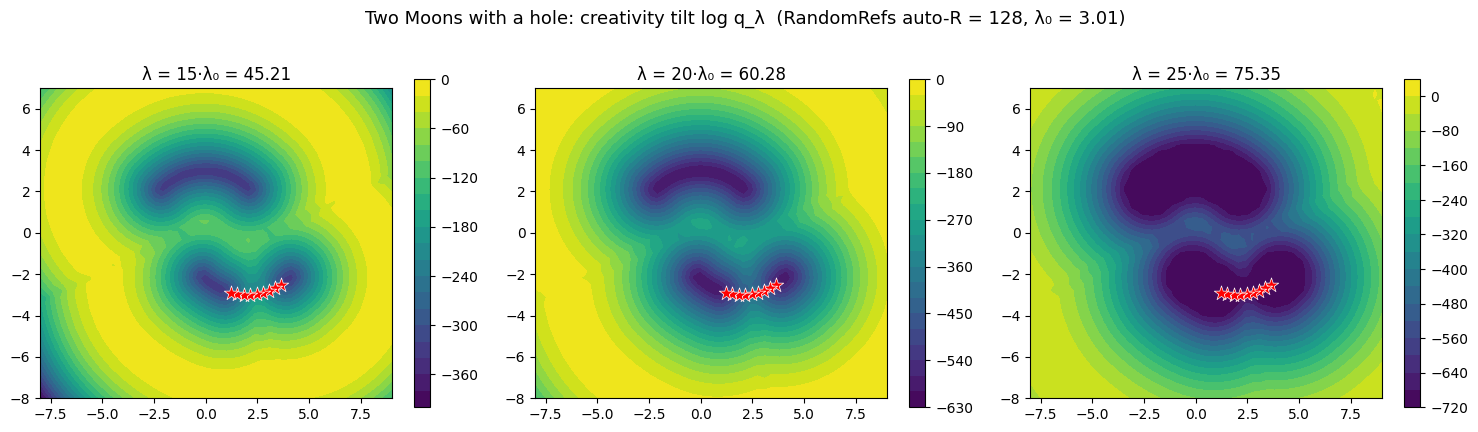

In [37]:
# Two Moons with a hole — log q_λ at λ = m·λ₀ for m ∈ {2.5, 3, 3.5} (per-density λ₀; RandomRefs auto-R).
LAMBDA_MULTS = [15, 20, 25]
fig, _ = lambda_sweep(
    log_p_grid_moons2, f_grid_mh, cell_area, XX, YY,
    lambda0=LAMBDA_0_mh, multipliers=LAMBDA_MULTS,
    panel_titles=[f"λ = {m:g}·λ₀ = {m*LAMBDA_0_mh:.2f}" for m in LAMBDA_MULTS],
    missing=MISSING, ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Two Moons with a hole: creativity tilt log q_λ  (RandomRefs auto-R = {R_mh}, λ₀ = {LAMBDA_0_mh:.2f})",
             fontsize=13, y=1.03)
plt.show()

## Swiss Roll

In [38]:
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture

N_SAMPLES = 5000        # samples for fitting
N_COMPONENTS = 24       # GMM beads along the spiral
D = 2

# Generate and project to 2D (x-z plane, drop height)
X_np, t_np = make_swiss_roll(n_samples=N_SAMPLES, noise=0.0, random_state=42)
X2d_np = X_np[:, [0, 2]]

# Fit spherical GMM (per-component isotropic variance, like existing experiments)
gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type='spherical',
                      random_state=42).fit(X2d_np)

MEANS        = torch.tensor(gmm.means_,       dtype=dtype)   # (K, 2)
VARS         = torch.tensor(gmm.covariances_, dtype=dtype)   # (K,)  per-component variance
LOG_WEIGHTS  = torch.log(torch.tensor(gmm.weights_, dtype=dtype))  # (K,)
K = MEANS.shape[0]

def log_pX(x):
    diff    = x.unsqueeze(-2) - MEANS                          # (..., K, 2)
    quad    = diff.pow(2).sum(-1) / VARS                       # (..., K)
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * VARS) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def log_pY(y, gamma):
    gamma   = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var     = gamma**2 * VARS + gamma                          # (K,)
    diff    = y.unsqueeze(-2) - gamma * MEANS                  # (..., K, 2)
    quad    = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * var) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def roll_sample(n):
    idx = torch.multinomial(torch.exp(LOG_WEIGHTS), n, replacement=True)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype)

p_roll = Density(log_pX, log_pY, sample_fn=roll_sample, d=2)
print(f"Swiss Roll GMM: {K} components, fitted to {N_SAMPLES} 2D samples")

grid_points_roll, XX, YY, cell_area = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
log_p_grid_roll = p_roll.log_p_X(grid_points_roll)
x_refs = p_roll.sample(32, seed=123)
print(f"Grid: {grid_points_roll.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Swiss Roll GMM: 24 components, fitted to 5000 2D samples
Grid: 2500 points, cell_area=0.3748; refs: torch.Size([32, 2])


In [39]:
# Swiss Roll — adopted setting (Exp 1+2+3) with RandomRefs auto-R; γ-window & λ₀ recalibrated to THIS density.
import time
from refset import RandomRefs

C, N_GAMMA = 0.75, 50
S        = torch.sqrt(VARS).mean().item()           # per-component std (γ-window scale)
GAMMA_LO = 1.0 / (C * S) ** 2
GAMMA_HI = 2.0 ** 10
GAMMAS_r = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)

D_select = GeneralizedGlobalIEMDistance(p_roll, GAMMAS_r, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_roll, GAMMAS_r, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_r = RandomRefs(p_roll, distance=D_select,
                   auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256), tau_target=0.95,
                   seed=0, fallback="best", auto_r_draws=4, probe_size=64)

t0 = time.perf_counter()
refs_r = sel_r.select()                             # R=None -> auto-choose R via the τ-level rule
dt = time.perf_counter() - t0
R_r = refs_r.shape[0]
print(f"Swiss Roll: RandomRefs auto-R = {R_r}  (refs generated in {dt:.1f}s)")

# Tilt over the grid + per-density λ₀, both via the public expected_distance helper (uniform-weight mean).
f_grid_r   = expected_distance(D_refset, grid_points_roll, refs_r)
LAMBDA_0_r = (p_roll.log_p_X(refs_r).std()
              / expected_distance(D_refset, refs_r, refs_r).std()).item()

print(f"  chosen params: γ=[{GAMMA_LO:.3g}, {GAMMA_HI:.0f}], N_γ={N_GAMMA}, R={R_r}, λ₀={LAMBDA_0_r:.3g}")

Swiss Roll: RandomRefs auto-R = 64  (refs generated in 127.2s)
  chosen params: γ=[3.04, 1024], N_γ=50, R=64, λ₀=4.26


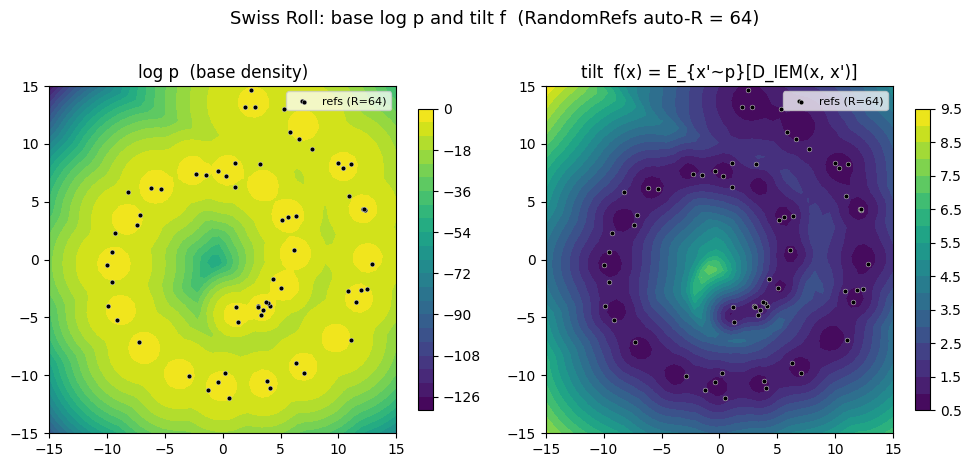

In [40]:
# Swiss Roll — components of log q_λ: (left) base log p,  (right) tilt f(x) = E_{x'~p}[D_IEM(x, x')].
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_roll, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_r)
plot_field(f_grid_r,        XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_r)
fig.suptitle(f"Swiss Roll: base log p and tilt f  (RandomRefs auto-R = {R_r})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

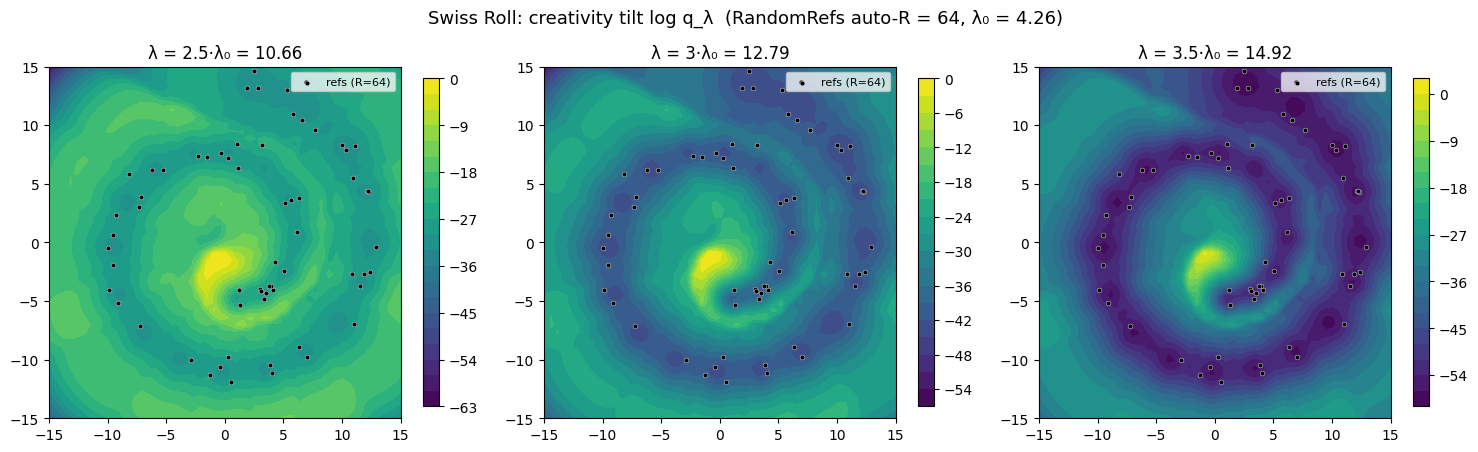

In [41]:
# Swiss Roll — log q_λ at λ = m·λ₀ for m ∈ {2.5, 3, 3.5} (per-density λ₀; RandomRefs auto-R).
LAMBDA_MULTS = [2.5, 3.0, 3.5]
fig, _ = lambda_sweep(
    log_p_grid_roll, f_grid_r, cell_area, XX, YY,
    lambda0=LAMBDA_0_r, multipliers=LAMBDA_MULTS,
    panel_titles=[f"λ = {m:g}·λ₀ = {m*LAMBDA_0_r:.2f}" for m in LAMBDA_MULTS],
    refs=refs_r, ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Swiss Roll: creativity tilt log q_λ  (RandomRefs auto-R = {R_r}, λ₀ = {LAMBDA_0_r:.2f})",
             fontsize=13, y=1.03)
plt.show()

# Fixes for Two Moons (diagnosis-driven)

Diagnosis: the tilt field `f(x) = E_{x'~p}[D_IEM(x, x')]` grows **monotonically off-manifold in every density** (confirmed: `corr(f, log p) ≈ -0.95` for ring, swiss roll, and moons alike). Closed / holed manifolds (ring, swiss roll) enclose a *bounded* low-density pocket, so `q_λ = p·e^{λ f}` settles there for a range of λ — a usable creative window. Two **open** crescents enclose nothing: once λ pulls mass off the arcs it slides continuously to the grid edge, so there is no stable "novel-but-plausible" regime. The sections below test three fixes, one by one, on the plain Two Moons density.

## Fix 1 — shrink the grid to the data bounding box

The original moons grid `x[-8,9], y[-8,7]` is huge relative to the data (`x≈[-2,4], y≈[-3,3]`). That oversized off-manifold rim is exactly where `f` is largest, giving the runaway somewhere to run. Here the grid is the data bbox + a small margin; refs, γ-window and λ₀ are identical to the baseline.

In [42]:
# Fix 1 — Two Moons on a tight grid (data bbox + margin). Density identical to the baseline Two Moons.
import time
from refset import RandomRefs

K_PER_MOON, SIGMA = 16, 0.18
S2 = SIGMA ** 2
ARC, RADIUS, H_SHIFT, V_SHIFT = 0.5 * math.pi, 3, 2, 0.0
t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
MEANS = torch.cat([moon1, moon2], dim=0)
K = MEANS.shape[0]; logK = math.log(K); Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2), dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var), dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons_f1 = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)

# Tight grid = data bbox + margin (baseline grid was x[-8,9], y[-8,7]).
PAD = 1.5
xlo, xhi = MEANS[:, 0].min().item() - PAD, MEANS[:, 0].max().item() + PAD
ylo, yhi = MEANS[:, 1].min().item() - PAD, MEANS[:, 1].max().item() + PAD
grid_points_f1, XX, YY, cell_area = make_grid((xlo, xhi), (ylo, yhi), grid_n=50, dtype=dtype)
log_p_grid_f1 = p_moons_f1.log_p_X(grid_points_f1)

C, N_GAMMA = 0.75, 50
GAMMA_LO, GAMMA_HI = 1.0 / (C * SIGMA) ** 2, 2.0 ** 10
GAMMAS_f1 = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2, dtype=dtype)
D_select = GeneralizedGlobalIEMDistance(p_moons_f1, GAMMAS_f1, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_moons_f1, GAMMAS_f1, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)

sel_f1 = RandomRefs(p_moons_f1, distance=D_select, auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256),
                    tau_target=0.95, seed=0, fallback="best", auto_r_draws=4, probe_size=64)
t0 = time.perf_counter(); refs_f1 = sel_f1.select(); R_f1 = refs_f1.shape[0]
print(f"Fix 1 (tight grid): RandomRefs auto-R = {R_f1}  (in {time.perf_counter()-t0:.1f}s)")

f_grid_f1   = expected_distance(D_refset, grid_points_f1, refs_f1)
LAMBDA_0_f1 = (p_moons_f1.log_p_X(refs_f1).std()
               / expected_distance(D_refset, refs_f1, refs_f1).std()).item()
print(f"  grid: x[{xlo:.1f},{xhi:.1f}] y[{ylo:.1f},{yhi:.1f}] (PAD={PAD}); R={R_f1}, lambda0={LAMBDA_0_f1:.3f}")

Fix 1 (tight grid): RandomRefs auto-R = 16  (in 131.6s)
  grid: x[-3.6,5.6] y[-4.5,4.5] (PAD=1.5); R=16, lambda0=2.614


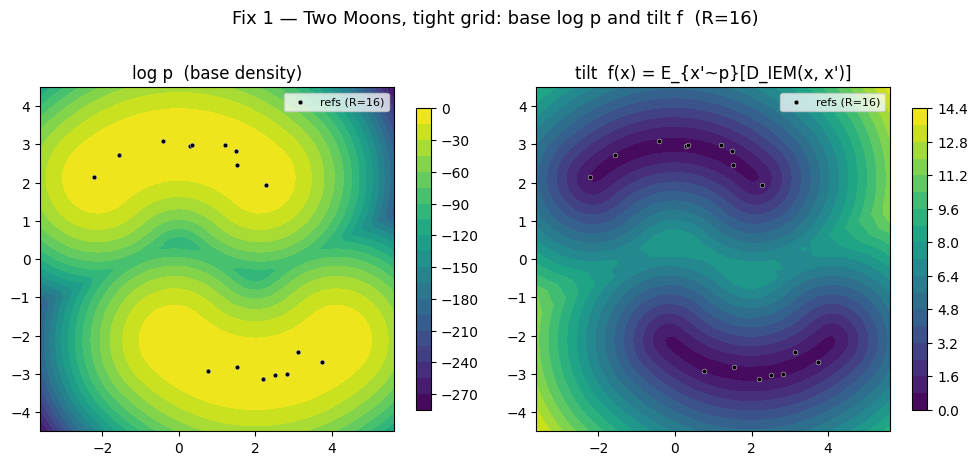

In [43]:
# Fix 1 — components of log q_lambda: (left) base log p, (right) tilt f.
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_f1, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_f1)
plot_field(f_grid_f1,     XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_f1)
fig.suptitle(f"Fix 1 — Two Moons, tight grid: base log p and tilt f  (R={R_f1})", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

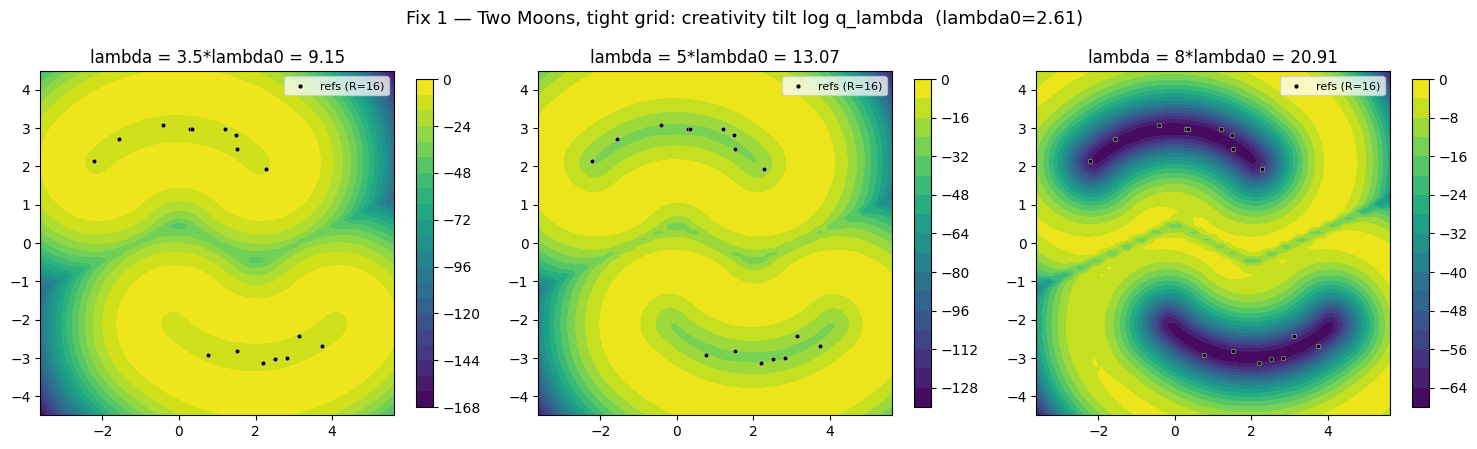

In [44]:
# Fix 1 — log q_lambda at lambda = m*lambda0 for m in {3.5, 5, 8} (creative window emerges around m~5-8).
LAMBDA_MULTS = [3.5, 5, 8]
fig, _ = lambda_sweep(
    log_p_grid_f1, f_grid_f1, cell_area, XX, YY,
    lambda0=LAMBDA_0_f1, multipliers=LAMBDA_MULTS,
    panel_titles=[f"lambda = {m:g}*lambda0 = {m*LAMBDA_0_f1:.2f}" for m in LAMBDA_MULTS],
    refs=refs_f1, ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Fix 1 — Two Moons, tight grid: creativity tilt log q_lambda  (lambda0={LAMBDA_0_f1:.2f})",
             fontsize=13, y=1.03)
plt.show()

In [45]:
# Fix 1 — extra test: where does q-mass land vs the full-grid baseline?
# Reports the log-p percentile of the q-peak and the share of mass in the moderate-density
# "novel-but-plausible" band (10-60 pctile) vs the deep tail (<10 pctile).
f  = f_grid_f1.detach().flatten().double(); lp = log_p_grid_f1.detach().flatten().double()
gx, gy = grid_points_f1[:, 0].double(), grid_points_f1[:, 1].double()
lp_rank = lp.argsort().argsort().double() / (len(lp) - 1) * 100
print("Fix 1 (tight grid) — q-mass scan:")
for m in [2.5, 3.5, 5, 8, 12]:
    q = torch.softmax(lp + m * LAMBDA_0_f1 * f, 0); i = torch.argmax(q)
    band = q[(lp_rank >= 10) & (lp_rank <= 60)].sum() * 100
    tail = q[lp_rank < 10].sum() * 100
    print(f"  m={m:>4}: peak=({gx[i]:5.1f},{gy[i]:5.1f}) logp-pctile={lp_rank[i]:5.1f}% "
          f"| 10-60% band={band:5.1f}%  deep-tail(<10%)={tail:5.1f}%")
print("Read: a healthy creative regime puts mass in the 10-60% band with ~0% in the deep tail.")

Fix 1 (tight grid) — q-mass scan:
  m= 2.5: peak=(  2.6,  2.7) logp-pctile= 80.6% | 10-60% band=  0.0%  deep-tail(<10%)=  0.0%
  m= 3.5: peak=(  2.6,  3.0) logp-pctile= 71.0% | 10-60% band=  4.0%  deep-tail(<10%)=  0.0%
  m=   5: peak=(  5.4, -1.7) logp-pctile= 56.5% | 10-60% band= 70.6%  deep-tail(<10%)=  0.0%
  m=   8: peak=(  4.3,  2.3) logp-pctile= 25.3% | 10-60% band=100.0%  deep-tail(<10%)=  0.0%
  m=  12: peak=(  5.4,  2.3) logp-pctile=  4.5% | 10-60% band=  0.5%  deep-tail(<10%)= 99.5%
Read: a healthy creative regime puts mass in the 10-60% band with ~0% in the deep tail.


## Fix 2 — cap / saturate the tilt field

`f` grows without bound off-manifold (`f ≈ ‖x − E[X|y]‖`, the denoising error). Capping it removes the runaway's reward for going ever further out. Here we **winsorize** the baseline Two Moons tilt at its 90th percentile (a smooth `log1p` alternative is shown in the diagnostic). Reuses the field `f_grid_m`, `log_p_grid_moons`, `refs_m`, `LAMBDA_0_m` from the **Two Moons** section above (no recompute).

In [46]:
# Fix 2 — cap the baseline Two Moons tilt field at its 90th percentile.
# Regenerate the moons full-grid mesh (XX/YY get overwritten by later sections); f_grid_m aligns with it.
grid_points_moons_chk, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)

F_CAP_Q = 0.90
f_cap = torch.clamp(f_grid_m, max=torch.quantile(f_grid_m, F_CAP_Q))
print(f"Fix 2: capped tilt at the {F_CAP_Q:.0%} pctile "
      f"({torch.quantile(f_grid_m, F_CAP_Q):.3f}); raw max was {f_grid_m.max():.3f}")

Fix 2: capped tilt at the 90% pctile (21.310); raw max was 32.124


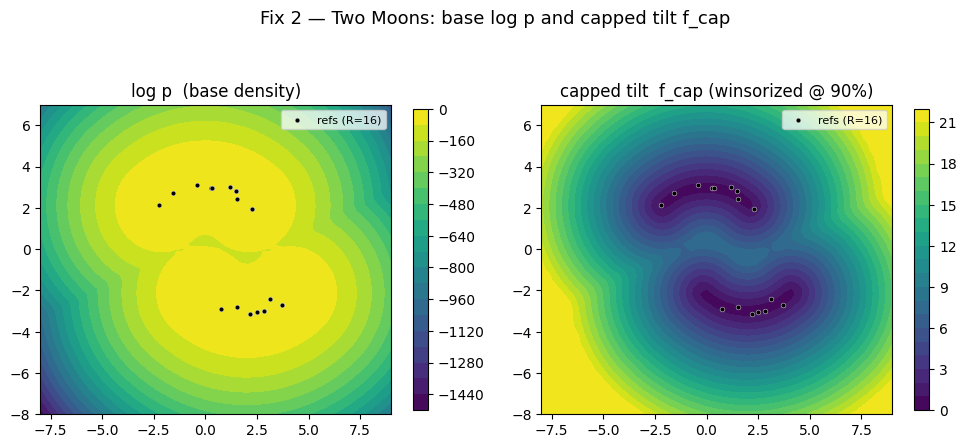

In [47]:
# Fix 2 — components: (left) base log p, (right) capped tilt f_cap.
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_moons, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_m)
plot_field(f_cap,            XX, YY, ax=axes[1], title=f"capped tilt  f_cap (winsorized @ {F_CAP_Q:.0%})", refs=refs_m)
fig.suptitle("Fix 2 — Two Moons: base log p and capped tilt f_cap", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

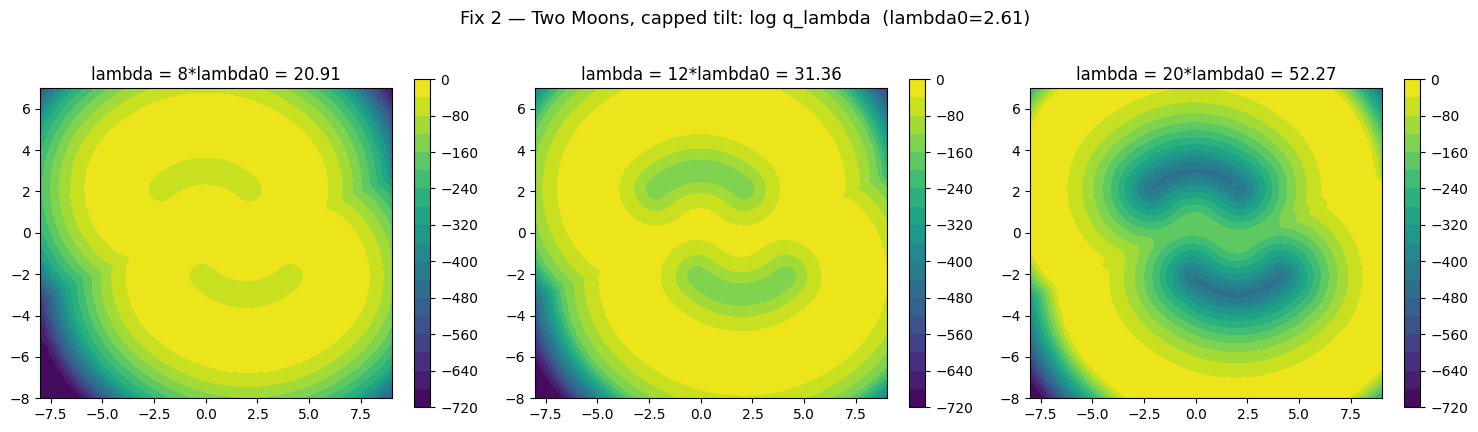

In [48]:
# Fix 2 — log q_lambda with the capped tilt, m in {8, 12, 20} (creative window ~ m 12-20).
LAMBDA_MULTS = [8, 12, 20]
fig, _ = lambda_sweep(
    log_p_grid_moons, f_cap, cell_area, XX, YY,
    lambda0=LAMBDA_0_m, multipliers=LAMBDA_MULTS,
    panel_titles=[f"lambda = {m:g}*lambda0 = {m*LAMBDA_0_m:.2f}" for m in LAMBDA_MULTS],
    ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Fix 2 — Two Moons, capped tilt: log q_lambda  (lambda0={LAMBDA_0_m:.2f})", fontsize=13, y=1.03)
plt.show()

In [49]:
# Fix 2 — extra test: raw vs capped vs smooth-saturating (log1p) tilt, q-mass scan.
lp = log_p_grid_moons.detach().flatten().double()
lp_rank = lp.argsort().argsort().double() / (len(lp) - 1) * 100
variants = {
    "raw f":            f_grid_m.detach().flatten().double(),
    "capped @90%":      torch.clamp(f_grid_m, max=torch.quantile(f_grid_m, 0.90)).detach().flatten().double(),
    "log1p(f) (smooth)": torch.log1p(f_grid_m).detach().flatten().double(),
}
for name, fv in variants.items():
    print(f"-- {name} --")
    for m in [5, 12, 20]:
        q = torch.softmax(lp + m * LAMBDA_0_m * fv, 0)
        band = q[(lp_rank >= 10) & (lp_rank <= 60)].sum() * 100
        tail = q[lp_rank < 10].sum() * 100
        print(f"   m={m:>4}: 10-60% band={band:5.1f}%  deep-tail={tail:5.1f}%")
print("Read: capping/saturating keeps deep-tail ~0% while opening a 10-60% band -> no runaway to the edge.")

-- raw f --
   m=   5: 10-60% band=  0.0%  deep-tail=  0.0%
   m=  12: 10-60% band= 95.3%  deep-tail=  0.0%
   m=  20: 10-60% band=100.0%  deep-tail=  0.0%
-- capped @90% --
   m=   5: 10-60% band=  0.0%  deep-tail=  0.0%
   m=  12: 10-60% band= 95.3%  deep-tail=  0.0%
   m=  20: 10-60% band=100.0%  deep-tail=  0.0%
-- log1p(f) (smooth) --
   m=   5: 10-60% band=  0.0%  deep-tail=  0.0%
   m=  12: 10-60% band=  0.0%  deep-tail=  0.0%
   m=  20: 10-60% band=  0.0%  deep-tail=  0.0%
Read: capping/saturating keeps deep-tail ~0% while opening a 10-60% band -> no runaway to the edge.


## Fix 3 — recalibrate λ₀ to the field's grid-scale spread

The default `λ₀ = std(log p @ refs) / std(D_IEM among refs)` calibrates to the *pairwise spread of references*, which is large for the long moon arcs → small `λ₀` → the huge multipliers the moons needed. Calibrating instead to the **grid-scale spread of the tilt** (`std(log p over grid) / std(f over grid)`) ties λ to the off-manifold slope that actually competes with `log p`. Reuses the baseline `f_grid_m`, `log_p_grid_moons` (no recompute).

In [50]:
# Fix 3 — recalibrate lambda0 from ref-pairwise-spread to grid-scale spread of the tilt.
grid_points_moons_chk, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)

LAMBDA_0_grid = (log_p_grid_moons.std() / f_grid_m.std()).item()
print(f"Fix 3: lambda0 (ref-spread) = {LAMBDA_0_m:.3f}  ->  lambda0 (grid-spread) = {LAMBDA_0_grid:.3f}")
print("       i.e. the canonical multiplier m~1 now lands in the creative regime.")

Fix 3: lambda0 (ref-spread) = 2.614  ->  lambda0 (grid-spread) = 39.488
       i.e. the canonical multiplier m~1 now lands in the creative regime.


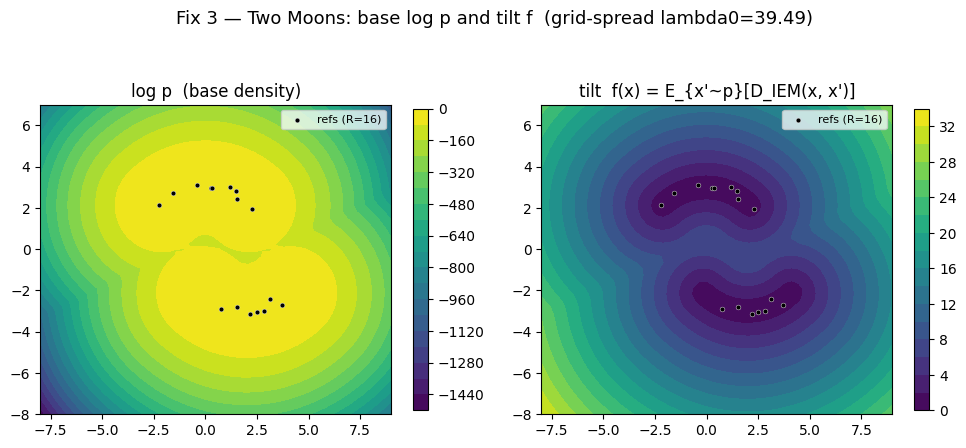

In [51]:
# Fix 3 — components: (left) base log p, (right) tilt f (same field; only lambda0 changes).
fig, axes = plt.subplots(1, 2, figsize=(5.0 * 2, 4.4))
plot_field(log_p_grid_moons, XX, YY, ax=axes[0], title="log p  (base density)", refs=refs_m)
plot_field(f_grid_m,         XX, YY, ax=axes[1], title="tilt  f(x) = E_{x'~p}[D_IEM(x, x')]", refs=refs_m)
fig.suptitle(f"Fix 3 — Two Moons: base log p and tilt f  (grid-spread lambda0={LAMBDA_0_grid:.2f})",
             fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

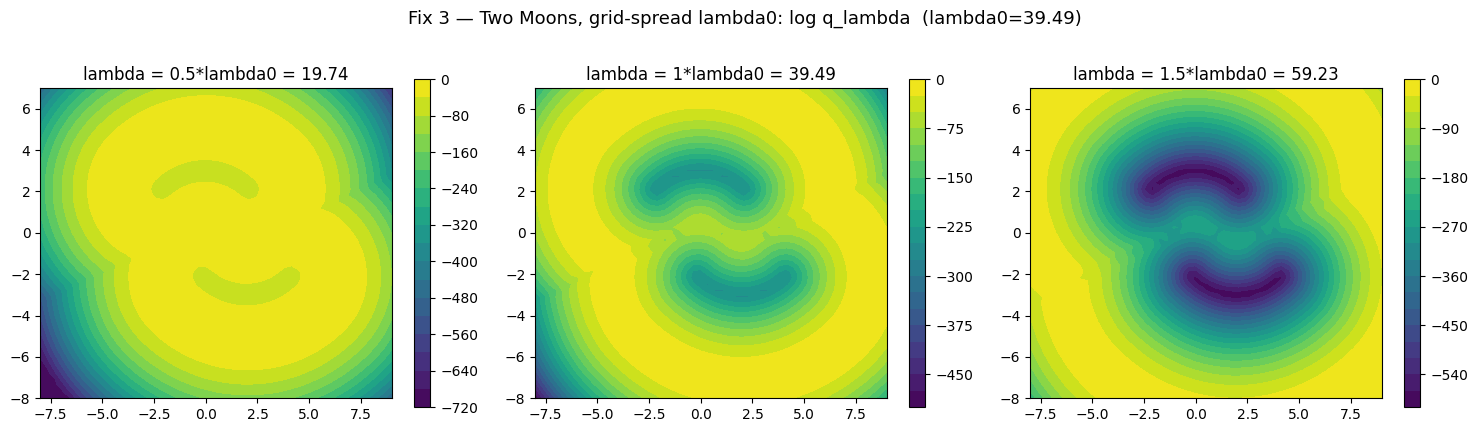

In [52]:
# Fix 3 — log q_lambda with the recalibrated lambda0, m in {0.5, 1, 1.5}.
LAMBDA_MULTS = [0.5, 1.0, 1.5]
fig, _ = lambda_sweep(
    log_p_grid_moons, f_grid_m, cell_area, XX, YY,
    lambda0=LAMBDA_0_grid, multipliers=LAMBDA_MULTS,
    panel_titles=[f"lambda = {m:g}*lambda0 = {m*LAMBDA_0_grid:.2f}" for m in LAMBDA_MULTS],
    ncols=3, panel_w=5.0, panel_h=4.4,
)
fig.suptitle(f"Fix 3 — Two Moons, grid-spread lambda0: log q_lambda  (lambda0={LAMBDA_0_grid:.2f})",
             fontsize=13, y=1.03)
plt.show()

In [53]:
# Fix 3 — extra test: q-mass scan under the two lambda0 conventions (same field, same density).
lp = log_p_grid_moons.detach().flatten().double()
f  = f_grid_m.detach().flatten().double()
lp_rank = lp.argsort().argsort().double() / (len(lp) - 1) * 100
for tag, lam0, mults in [("ref-spread lambda0", LAMBDA_0_m,    [2.5, 3.5, 5]),
                         ("grid-spread lambda0", LAMBDA_0_grid, [0.5, 1.0, 1.5])]:
    print(f"-- {tag} = {lam0:.3f} --")
    for m in mults:
        q = torch.softmax(lp + m * lam0 * f, 0); i = torch.argmax(q)
        band = q[(lp_rank >= 10) & (lp_rank <= 60)].sum() * 100
        tail = q[lp_rank < 10].sum() * 100
        print(f"   m={m:>4} (lambda={m*lam0:6.2f}): logp-pctile={lp_rank[i]:5.1f}% "
              f"| 10-60% band={band:5.1f}%  deep-tail={tail:5.1f}%")
print("Read: grid-spread lambda0 puts the creative regime near m~1 (vs needing m~12-25 with ref-spread).")

-- ref-spread lambda0 = 2.614 --
   m= 2.5 (lambda=  6.53): logp-pctile= 94.8% | 10-60% band=  0.0%  deep-tail=  0.0%
   m= 3.5 (lambda=  9.15): logp-pctile= 90.6% | 10-60% band=  0.0%  deep-tail=  0.0%
   m=   5 (lambda= 13.07): logp-pctile= 86.0% | 10-60% band=  0.0%  deep-tail=  0.0%
-- grid-spread lambda0 = 39.488 --
   m= 0.5 (lambda= 19.74): logp-pctile= 74.6% | 10-60% band=  0.0%  deep-tail=  0.0%
   m= 1.0 (lambda= 39.49): logp-pctile= 41.7% | 10-60% band=100.0%  deep-tail=  0.0%
   m= 1.5 (lambda= 59.23): logp-pctile= 12.5% | 10-60% band= 92.2%  deep-tail=  7.8%
Read: grid-spread lambda0 puts the creative regime near m~1 (vs needing m~12-25 with ref-spread).


## γ₀ × λ sweep — Two Moons (baseline density, f = identity)

Two Moons exactly as originally defined (full grid `x[-8,9], y[-8,7]`), `λ₀` via the original ref-spread method, `f = identity`. The grid below has **one column per γ₀ value** (`γ₀·2^k`, k = 0…4 → the lowest integration γ is raised, dropping high-noise contributions) and **one row per λ multiplier** (shared across columns). The expensive tilt field is computed per γ₀ in the first cell; change `LAMBDA_MULTS` in the second cell (any length) and re-run only that cell — you get a `len(LAMBDA_MULTS) × 5` grid.

Note: `GAMMA_HI = 2^10` is fixed, so the largest γ₀ scales give a narrow window; raise `GAMMA_HI_gs` if you want wider windows at high scales.

In [54]:
# HEAVY block — compute the identity-f tilt field per gamma0 row. Re-run only when changing the gamma sweep.
import time
from refset import RandomRefs

# --- Two Moons baseline density (unchanged from the original section) ---
K_PER_MOON, SIGMA = 16, 0.18
S2 = SIGMA ** 2
ARC, RADIUS, H_SHIFT, V_SHIFT = 0.5 * math.pi, 3, 2, 3.0   # V_SHIFT: wider vertical gap between the moons
t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
MEANS = torch.cat([moon1, moon2], dim=0)
K = MEANS.shape[0]; logK = math.log(K); Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2), dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var), dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons_gs = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
grid_points_gs, XX_gs, YY_gs, cell_area_gs = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_gs = p_moons_gs.log_p_X(grid_points_gs)

# --- gamma sweep config: rows use GAMMA_0_BASE * 2^k ---
C, N_GAMMA_gs = 0.75, 50
GAMMA_0_BASE = 1.0 / (C * SIGMA) ** 2          # base lowest gamma (== original GAMMA_LO)
GAMMA_HI_gs  = 2.0 ** 10                         # fixed upper gamma
N_GAMMA0_ROWS = 5
GAMMA0_SCALES = [2 ** k for k in range(N_GAMMA0_ROWS)]   # 1, 2, 4, 8, 16

# --- refs + lambda0 computed once on the base window (shared across rows, 'as before'), f = identity ---
GAMMAS_base = torch.logspace(math.log2(GAMMA_0_BASE), math.log2(GAMMA_HI_gs), N_GAMMA_gs, base=2, dtype=dtype)
D_select = GeneralizedGlobalIEMDistance(p_moons_gs, GAMMAS_base, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_moons_gs, GAMMAS_base, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
sel_gs = RandomRefs(p_moons_gs, distance=D_select, auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256),
                    tau_target=0.95, seed=0, fallback="best", auto_r_draws=4, probe_size=64)
t0 = time.perf_counter(); refs_gs = sel_gs.select(); R_gs = refs_gs.shape[0]
LAMBDA_0_gs = (p_moons_gs.log_p_X(refs_gs).std()
               / expected_distance(D_refset, refs_gs, refs_gs).std()).item()
print(f"refs auto-R={R_gs}, lambda0={LAMBDA_0_gs:.3f}  (refs in {time.perf_counter()-t0:.1f}s)")

# --- per-row tilt field (heavy): one expected-distance field per gamma0 scale ---
F_FIELDS, GAMMA_WINDOWS = [], []
for k, scale in enumerate(GAMMA0_SCALES):
    g_lo = GAMMA_0_BASE * scale
    gammas_k = torch.logspace(math.log2(g_lo), math.log2(GAMMA_HI_gs), N_GAMMA_gs, base=2, dtype=dtype)
    D_k = GeneralizedGlobalIEMDistance(p_moons_gs, gammas_k, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
    tk = time.perf_counter()
    F_FIELDS.append(expected_distance(D_k, grid_points_gs, refs_gs))
    GAMMA_WINDOWS.append((g_lo, GAMMA_HI_gs))
    print(f"  row {k}: gamma0*{scale:<2d} -> window [{g_lo:.1f}, {GAMMA_HI_gs:.0f}]  ({time.perf_counter()-tk:.1f}s)")
print(f"done: {len(F_FIELDS)} tilt fields ready.")

refs auto-R=16, lambda0=2.614  (refs in 134.5s)
  row 0: gamma0*1  -> window [54.9, 1024]  (38.1s)
  row 1: gamma0*2  -> window [109.7, 1024]  (33.6s)
  row 2: gamma0*4  -> window [219.5, 1024]  (33.2s)
  row 3: gamma0*8  -> window [439.0, 1024]  (32.5s)
  row 4: gamma0*16 -> window [877.9, 1024]  (33.0s)
done: 5 tilt fields ready.


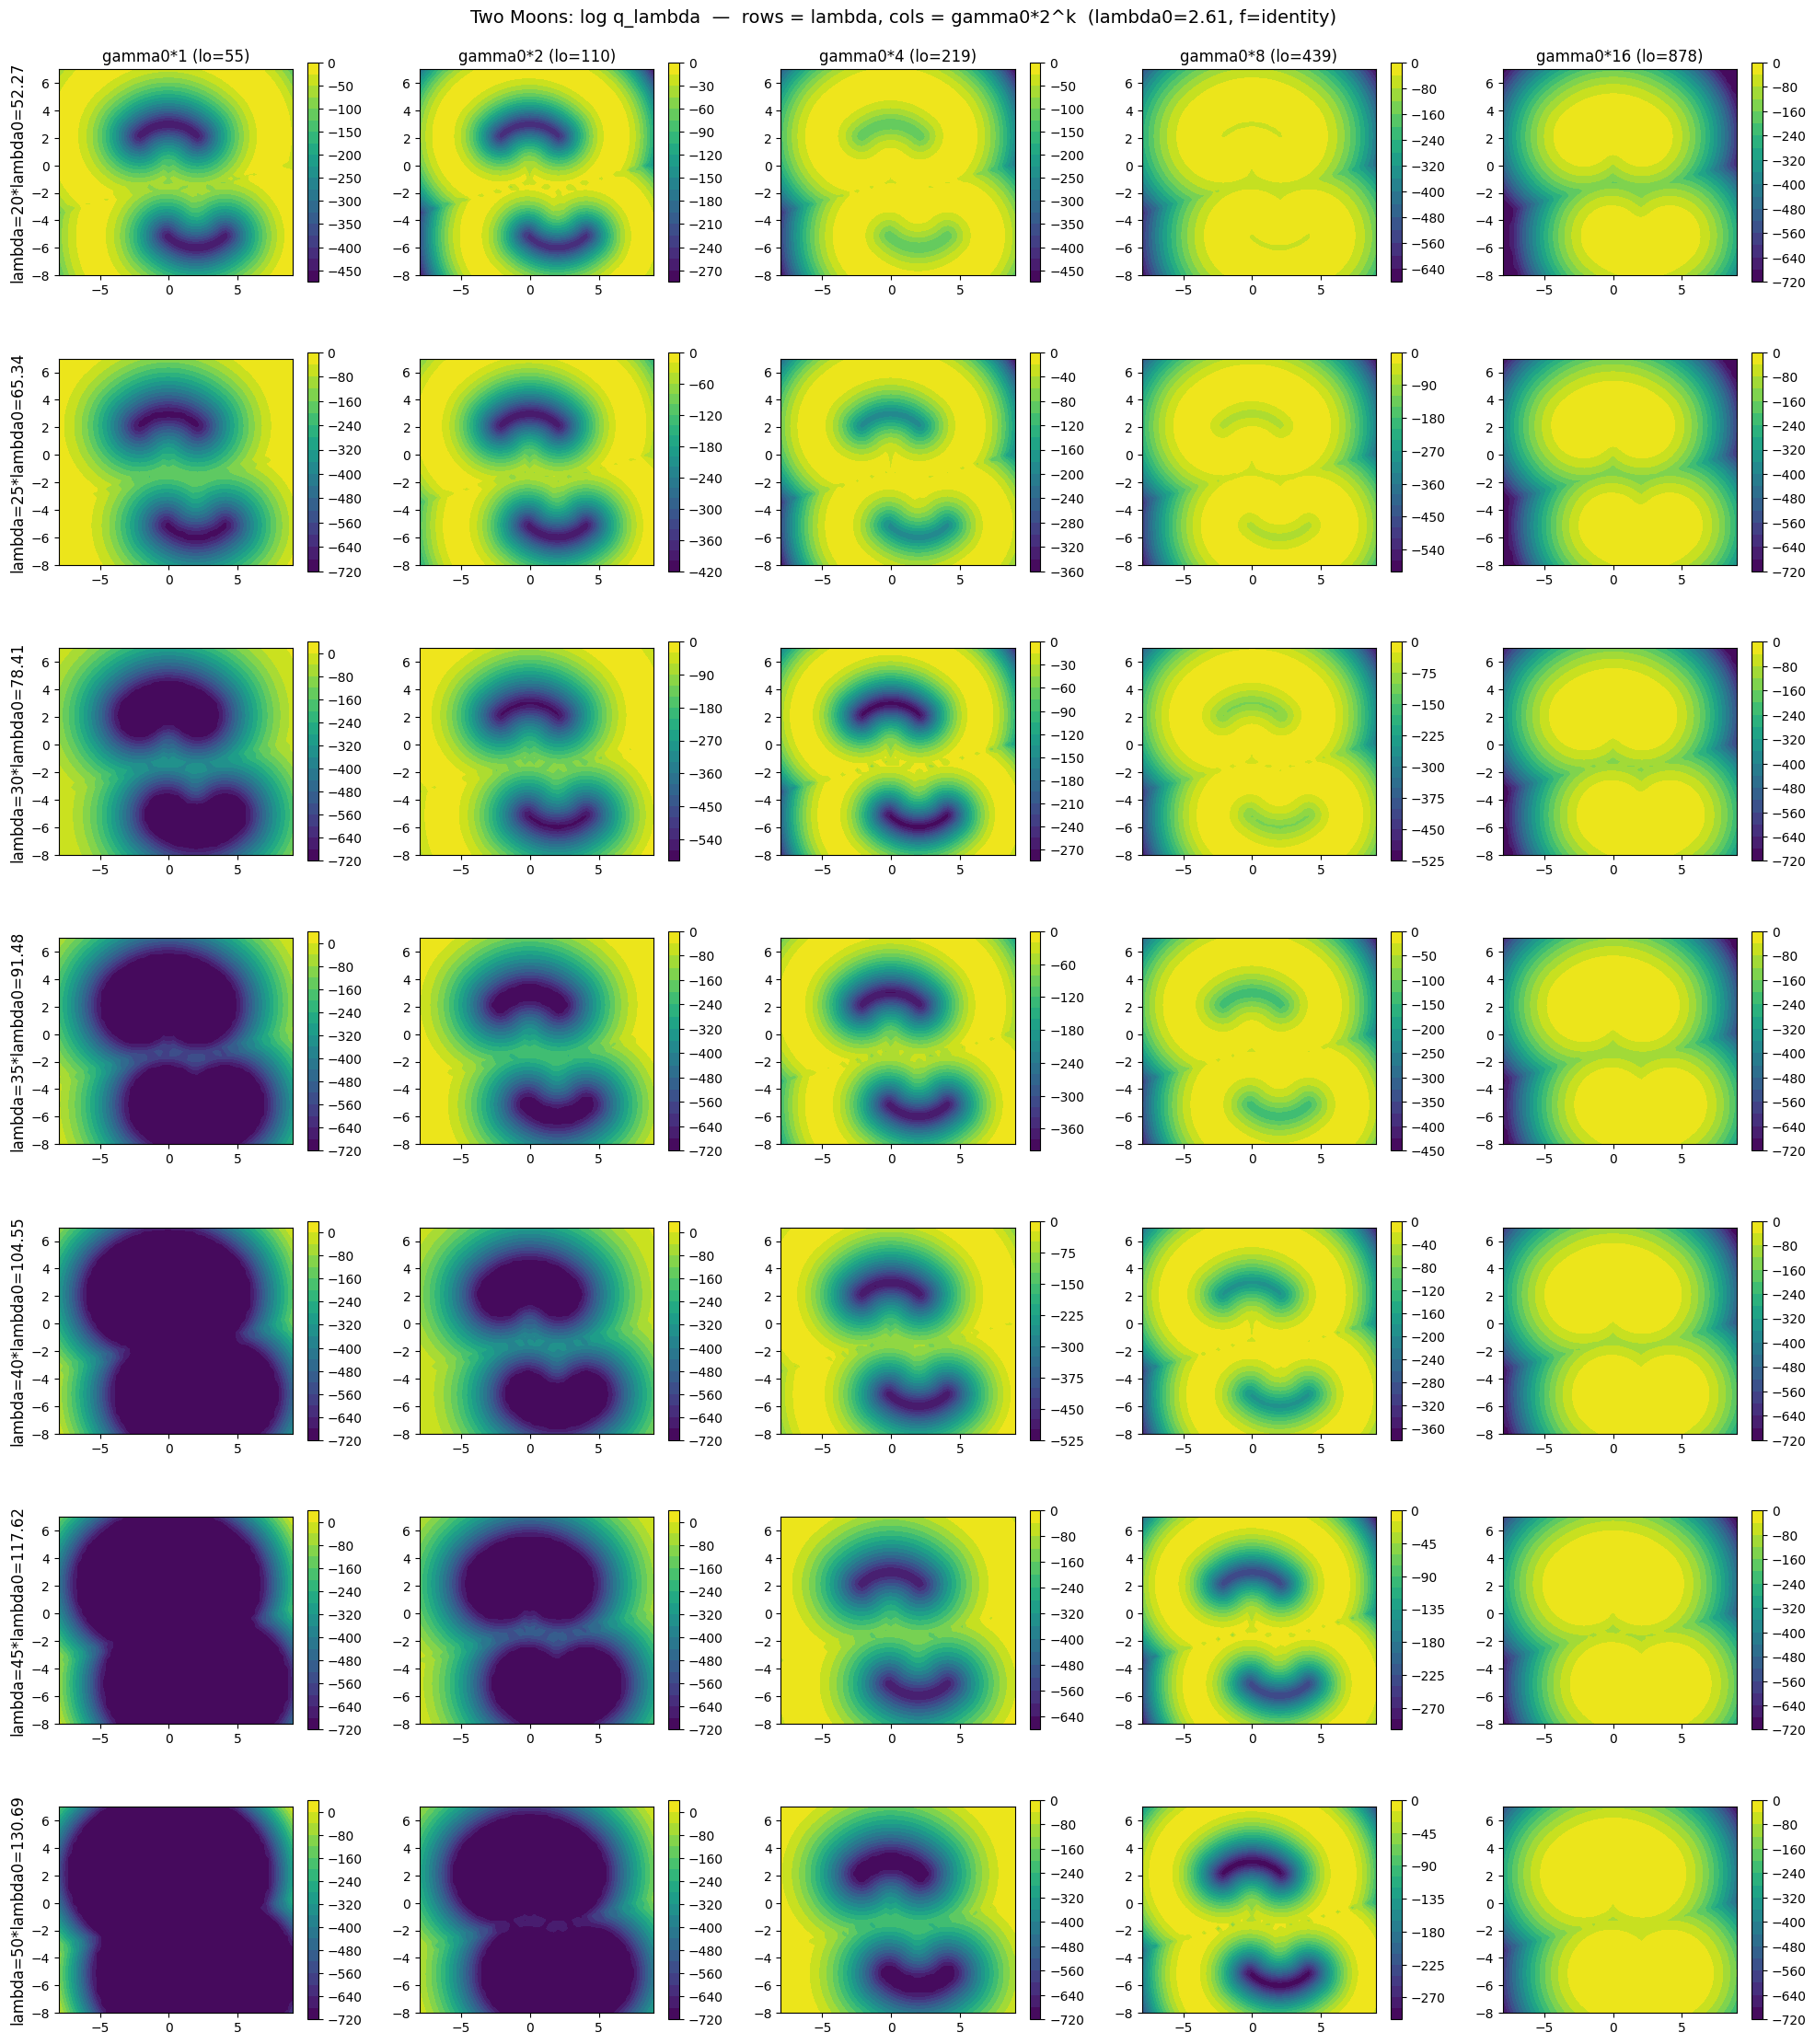

In [55]:
# LIGHT block — pick lambda multipliers (any length) and render the (lambda rows) x (gamma0 cols) grid.
# Change LAMBDA_MULTS and re-run ONLY this cell; the heavy fields above are reused.
LAMBDA_MULTS = [20, 25, 30, 35, 40, 45, 50]
fig, _ = lambda_sweep(
    log_p_grid_gs, list(F_FIELDS), cell_area_gs, XX_gs, YY_gs,
    lambda0=LAMBDA_0_gs, multipliers=LAMBDA_MULTS,
    field_labels=[f"gamma0*{s} (lo={lo:.0f})" for s, (lo, _) in zip(GAMMA0_SCALES, GAMMA_WINDOWS)],
    row_labels=[f"lambda={m:g}*lambda0={m*LAMBDA_0_gs:.2f}" for m in LAMBDA_MULTS],
    panel_w=4, panel_h=3.2,
)
fig.suptitle(f"Two Moons: log q_lambda  —  rows = lambda, cols = gamma0*2^k  "
             f"(lambda0={LAMBDA_0_gs:.2f}, f=identity)", fontsize=14, y=1.001)
plt.show()

In [56]:
# Re-run HEAVY block with V_SHIFT=3.0 (wider gap)
import time
from refset import RandomRefs

K_PER_MOON, SIGMA = 16, 0.18
S2 = SIGMA ** 2
ARC, RADIUS, H_SHIFT, V_SHIFT = 0.5 * math.pi, 3, 2, 3.0   # wider vertical gap
t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
MEANS = torch.cat([moon1, moon2], dim=0)
K = MEANS.shape[0]; logK = math.log(K); Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2), dim=-1) - logK
def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var), dim=-1) - logK
def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons_gs = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
print(f"moon1 y[{moon1[:,1].min():.2f},{moon1[:,1].max():.2f}]  moon2 y[{moon2[:,1].min():.2f},{moon2[:,1].max():.2f}]  -> gap ~{(moon1[:,1].min()-moon2[:,1].max()):.2f} units")

grid_points_gs, XX_gs, YY_gs, cell_area_gs = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_gs = p_moons_gs.log_p_X(grid_points_gs)

C, N_GAMMA_gs = 0.75, 50
GAMMA_0_BASE = 1.0 / (C * SIGMA) ** 2
GAMMA_HI_gs  = 2.0 ** 10
N_GAMMA0_ROWS = 5
GAMMA0_SCALES = [2 ** k for k in range(N_GAMMA0_ROWS)]

GAMMAS_base = torch.logspace(math.log2(GAMMA_0_BASE), math.log2(GAMMA_HI_gs), N_GAMMA_gs, base=2, dtype=dtype)
D_select = GeneralizedGlobalIEMDistance(p_moons_gs, GAMMAS_base, num_eps=6,           f_type=IEMFType.IDENTITY)
D_refset = GeneralizedGlobalIEMDistance(p_moons_gs, GAMMAS_base, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
sel_gs = RandomRefs(p_moons_gs, distance=D_select, auto_r_grid=(1, 2, 4, 8, 16, 32, 64, 128, 256),
                    tau_target=0.95, seed=0, fallback="best", auto_r_draws=4, probe_size=64)
t0 = time.perf_counter(); refs_gs = sel_gs.select(); R_gs = refs_gs.shape[0]
LAMBDA_0_gs = (p_moons_gs.log_p_X(refs_gs).std() / expected_distance(D_refset, refs_gs, refs_gs).std()).item()
print(f"refs auto-R={R_gs}, lambda0={LAMBDA_0_gs:.3f}  (refs in {time.perf_counter()-t0:.1f}s)")

F_FIELDS, GAMMA_WINDOWS = [], []
for k, scale in enumerate(GAMMA0_SCALES):
    g_lo = GAMMA_0_BASE * scale
    gammas_k = torch.logspace(math.log2(g_lo), math.log2(GAMMA_HI_gs), N_GAMMA_gs, base=2, dtype=dtype)
    D_k = GeneralizedGlobalIEMDistance(p_moons_gs, gammas_k, num_eps=EXP_NUM_EPS, f_type=IEMFType.IDENTITY)
    tk = time.perf_counter()
    F_FIELDS.append(expected_distance(D_k, grid_points_gs, refs_gs))
    GAMMA_WINDOWS.append((g_lo, GAMMA_HI_gs))
    print(f"  row {k}: gamma0*{scale:<2d} -> [{g_lo:.1f}, {GAMMA_HI_gs:.0f}]  ({time.perf_counter()-tk:.1f}s)")
print(f"done: {len(F_FIELDS)} fields.")


moon1 y[2.12,3.00]  moon2 y[-6.00,-5.12]  -> gap ~7.24 units
refs auto-R=16, lambda0=2.614  (refs in 129.3s)
  row 0: gamma0*1  -> [54.9, 1024]  (35.8s)
  row 1: gamma0*2  -> [109.7, 1024]  (36.0s)
  row 2: gamma0*4  -> [219.5, 1024]  (34.7s)
  row 3: gamma0*8  -> [439.0, 1024]  (33.5s)
  row 4: gamma0*16 -> [877.9, 1024]  (33.1s)
done: 5 fields.


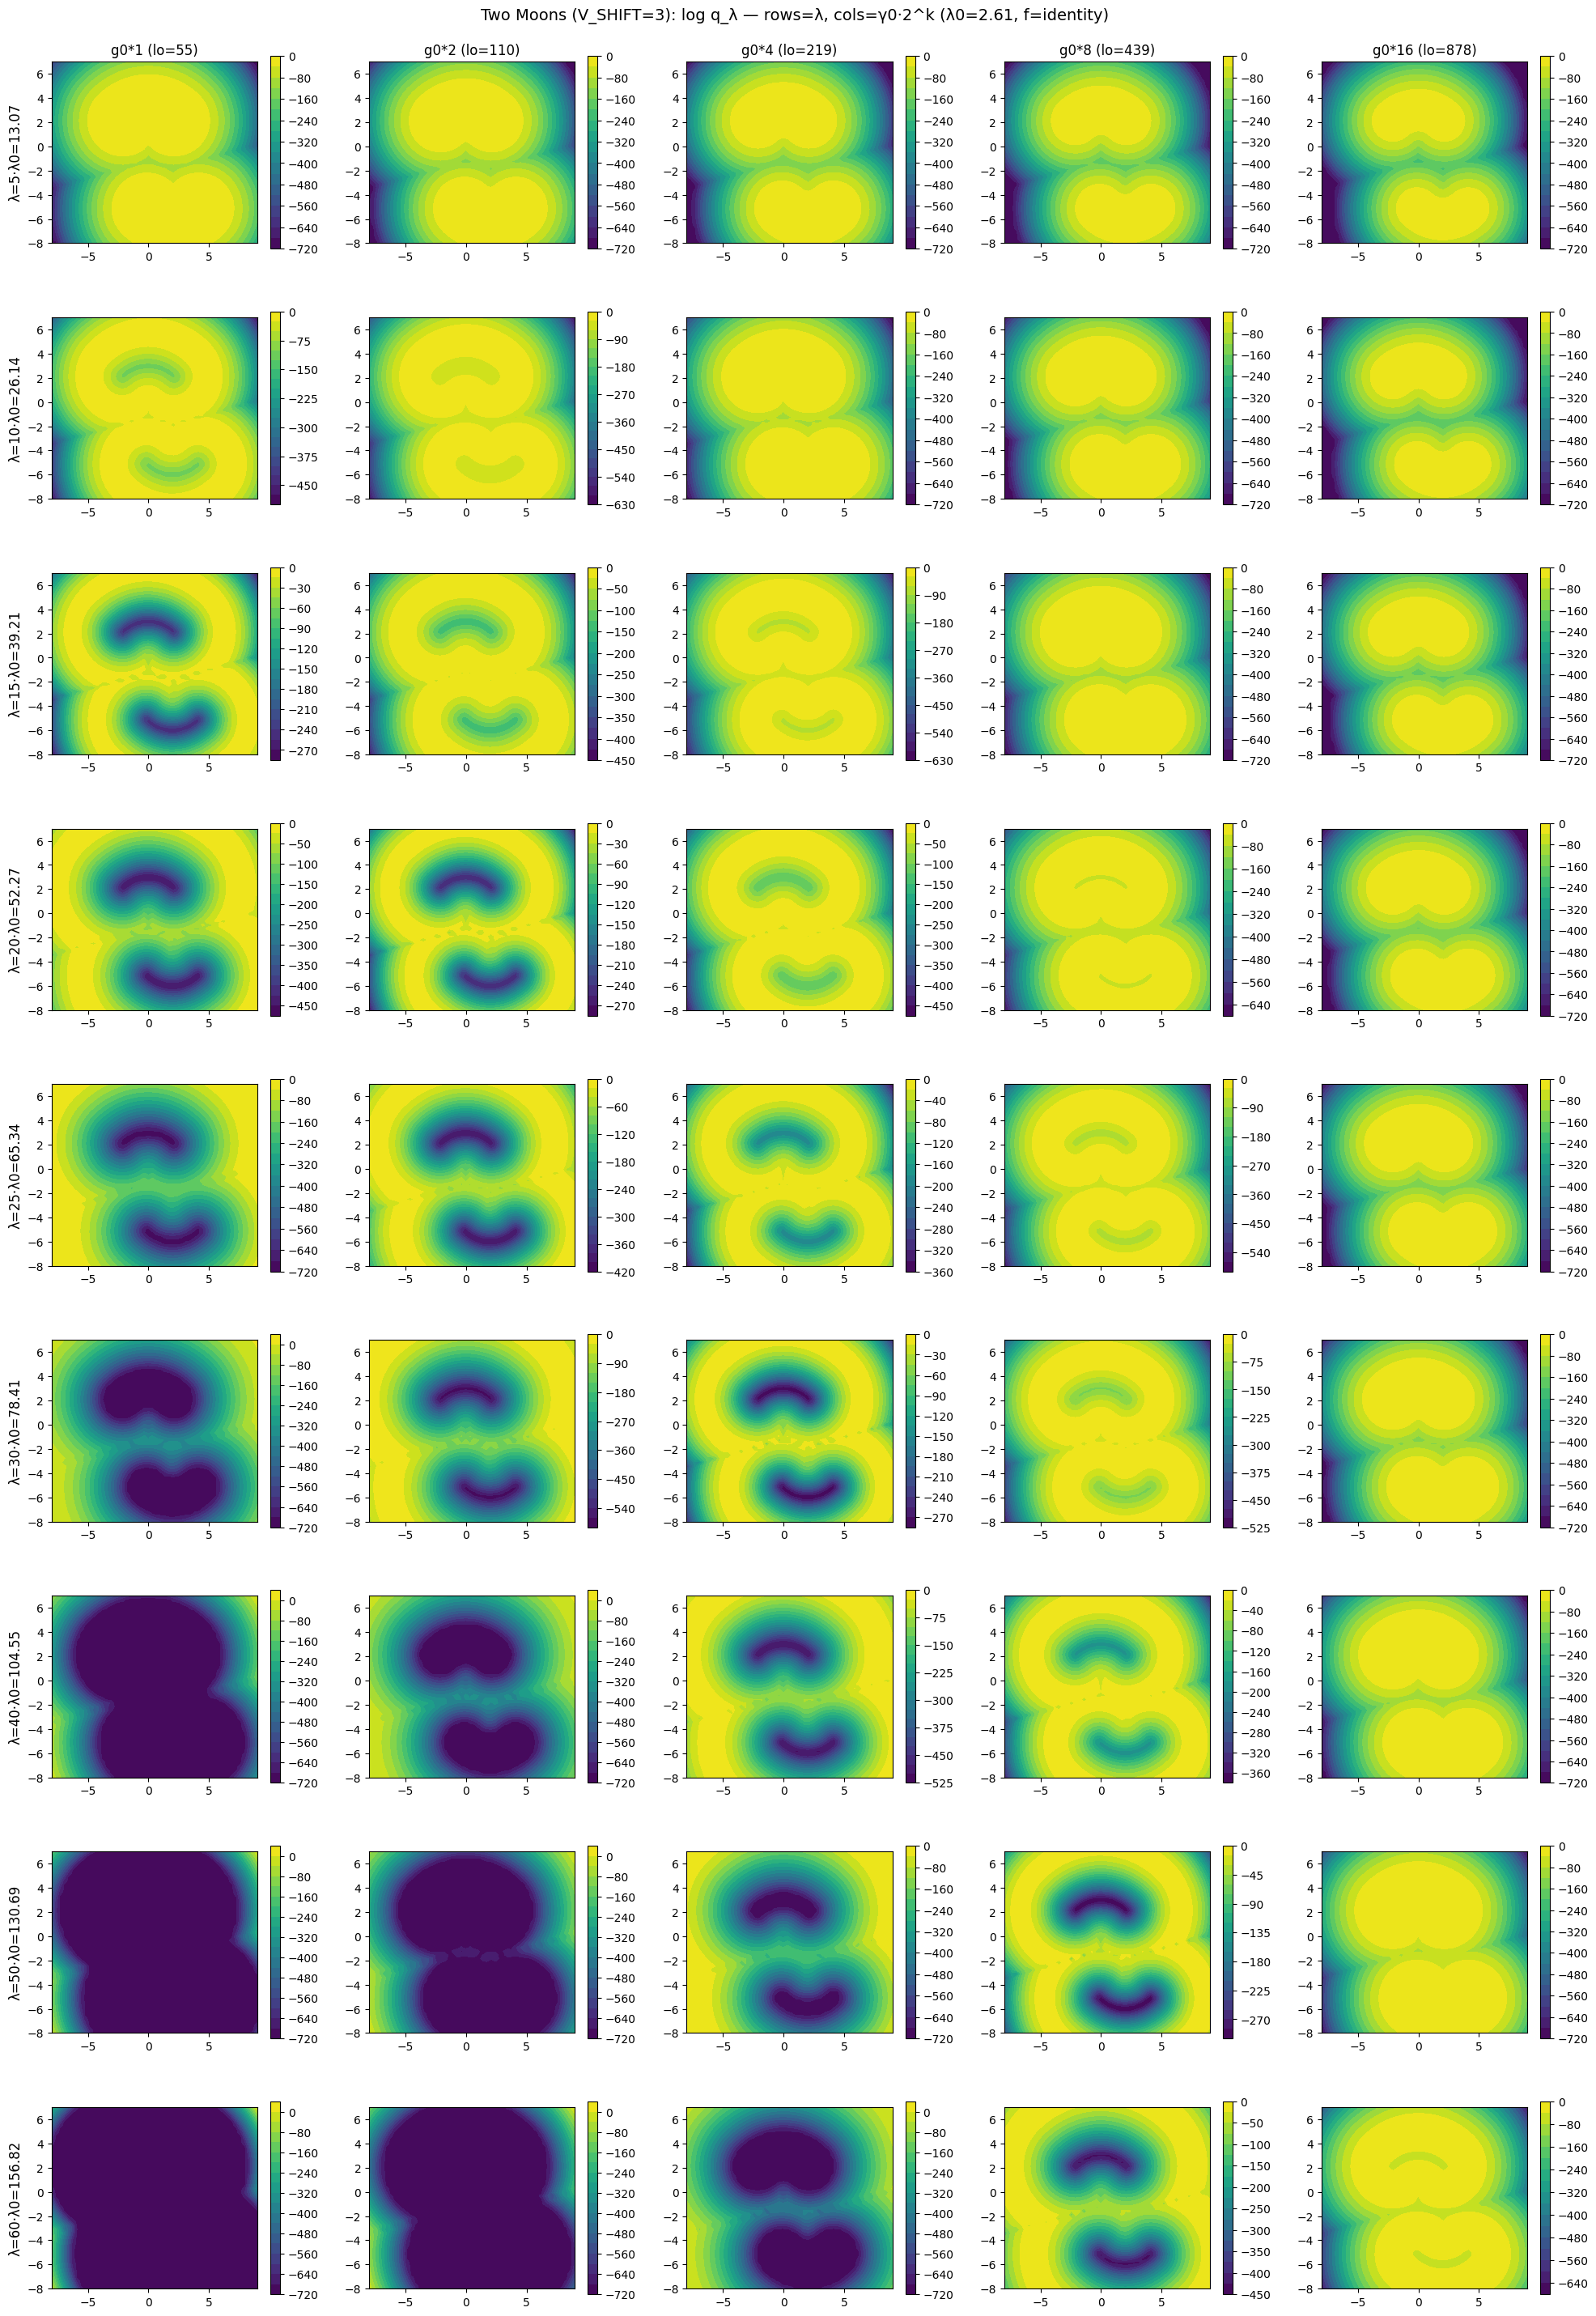

share of q-mass in the between-moons corridor:
  g0*1 : λ=5: 42.0%  λ=10: 33.2%  λ=15: 11.1%  λ=20:  0.0%  λ=25:  0.0%  λ=30:  0.0%  λ=40:  0.0%  λ=50:  0.0%  λ=60:  0.0%
  g0*2 : λ=5: 40.9%  λ=10: 38.1%  λ=15: 34.8%  λ=20: 11.7%  λ=25:  0.0%  λ=30:  0.0%  λ=40:  0.0%  λ=50:  0.0%  λ=60:  0.0%
  g0*4 : λ=5: 30.6%  λ=10: 42.0%  λ=15: 37.8%  λ=20: 37.6%  λ=25: 31.5%  λ=30:  7.5%  λ=40:  0.0%  λ=50:  0.0%  λ=60:  0.0%
  g0*8 : λ=5: 17.5%  λ=10: 37.3%  λ=15: 42.3%  λ=20: 40.4%  λ=25: 37.9%  λ=30: 38.8%  λ=40: 34.0%  λ=50:  5.8%  λ=60:  0.0%
  g0*16: λ=5:  6.7%  λ=10: 11.7%  λ=15: 19.0%  λ=20: 26.6%  λ=25: 33.6%  λ=30: 39.2%  λ=40: 42.4%  λ=50: 41.2%  λ=60: 39.3%


In [57]:
# LIGHT block
LAMBDA_MULTS = [5, 10, 15, 20, 25, 30, 40, 50, 60]
fig, _ = lambda_sweep(
    log_p_grid_gs, list(F_FIELDS), cell_area_gs, XX_gs, YY_gs,
    lambda0=LAMBDA_0_gs, multipliers=LAMBDA_MULTS,
    field_labels=[f"g0*{s} (lo={lo:.0f})" for s, (lo, _) in zip(GAMMA0_SCALES, GAMMA_WINDOWS)],
    row_labels=[f"λ={m:g}·λ0={m*LAMBDA_0_gs:.2f}" for m in LAMBDA_MULTS],
    panel_w=4, panel_h=3.2,
)
fig.suptitle(f"Two Moons (V_SHIFT=3): log q_λ — rows=λ, cols=γ0·2^k (λ0={LAMBDA_0_gs:.2f}, f=identity)", fontsize=14, y=1.001)
plt.show()

# Diagnostic: does q mass land in the empty corridor between the moons?
gx,gy = grid_points_gs[:,0].double(), grid_points_gs[:,1].double()
lp = log_p_grid_gs.detach().double()
corridor = (gy>-5.0)&(gy<2.0)&(gx>-3.0)&(gx<6.0)   # the empty band between the two arcs
print("share of q-mass in the between-moons corridor:")
for r in range(len(F_FIELDS)):
    row=[]
    for m in LAMBDA_MULTS:
        q=torch.softmax(lp+m*LAMBDA_0_gs*F_FIELDS[r].double(),0)
        row.append(f"{q[corridor].sum()*100:5.1f}%")
    print(f"  g0*{GAMMA0_SCALES[r]:<2d}: " + "  ".join(f"λ={m:g}:{v}" for m,v in zip(LAMBDA_MULTS,row)))